In [1]:
import matplotlib.pyplot as plt  
import seaborn as sns
import pandas as pd
import numpy as np
import random
import math

In [2]:
# No regulation
d_nr = pd.read_csv('csv/1.3/demand_{}.csv'.format('NO_REG'))
s_nr = pd.read_csv('csv/1.3/supply_{}.csv'.format('NO_REG'))
dist_d = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('NO_REG'))
dist_s = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('NO_REG'))

# Weak regulation
d_wr = pd.read_csv('csv/1.3/demand_{}.csv'.format('WEAK_REG_without_lockout'))
s_wr = pd.read_csv('csv/1.3/supply_{}.csv'.format('WEAK_REG_without_lockout'))
dist_dwr = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('WEAK_REG_without_lockout'))
dist_swr = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('WEAK_REG_without_lockout'))

# Weak regulation with lockout
d_wrl = pd.read_csv('csv/1.3/demand_{}.csv'.format('WEAK_REG_with_lockout'))
s_wrl = pd.read_csv('csv/1.3/supply_{}.csv'.format('WEAK_REG_with_lockout'))
dist_dwrl = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('WEAK_REG_with_lockout'))
dist_swrl = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('WEAK_REG_with_lockout'))

# Moderate regulation
d_mr = pd.read_csv('csv/1.3/demand_{}.csv'.format('MODERATE_REG_without_lockout'))
s_mr = pd.read_csv('csv/1.3/supply_{}.csv'.format('MODERATE_REG_without_lockout'))
dist_dmr = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('MODERATE_REG_without_lockout'))
dist_smr = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('MODERATE_REG_without_lockout'))

# Moderate regulation with lockout
d_mrl = pd.read_csv('csv/1.3/demand_{}.csv'.format('MODERATE_REG_with_lockout'))
s_mrl = pd.read_csv('csv/1.3/supply_{}.csv'.format('MODERATE_REG_with_lockout'))
dist_dmrl = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('MODERATE_REG_with_lockout'))
dist_smrl = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('MODERATE_REG_with_lockout'))

# Strong regulation
# STRONG_REG_without_lockout_2
d_sr = pd.read_csv('csv/1.3/demand_{}.csv'.format('STRONG_REG_without_lockout_2'))
s_sr = pd.read_csv('csv/1.3/supply_{}.csv'.format('STRONG_REG_without_lockout_2'))
dist_dsr = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('STRONG_REG_without_lockout_2'))
dist_ssr = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('STRONG_REG_without_lockout_2'))

# Strong regulation with lockout
d_srl = pd.read_csv('csv/1.3/demand_{}.csv'.format('STRONG_REG_with_lockout'))
s_srl = pd.read_csv('csv/1.3/supply_{}.csv'.format('STRONG_REG_with_lockout'))
dist_dsrl = pd.read_csv('csv/1.3/dist_demand_{}.csv'.format('STRONG_REG_with_lockout'))
dist_ssrl = pd.read_csv('csv/1.3/dist_supply_{}.csv'.format('STRONG_REG_with_lockout'))

In [3]:
def s_1(y, w=7, o=1, d=5):
    from scipy.signal import savgol_filter
    if len(y) < w:
        raise ValueError("Input data length must be greater than or equal to the window size (w).")
    nans = [float('nan') for _ in range(0, d)]
    smoothed = savgol_filter(y[d:], w, o)
    y = nans + list(smoothed)
    return y

def s_2(y, w=27, o=1, d=5):
    from scipy.signal import savgol_filter
    if len(y) < w:
        raise ValueError("Input data length must be greater than or equal to the window size (w).")
    nans = [float('nan') for _ in range(0, d)]
    smoothed = savgol_filter(y[d:], w, o)
    y = nans + list(smoothed)
    return y

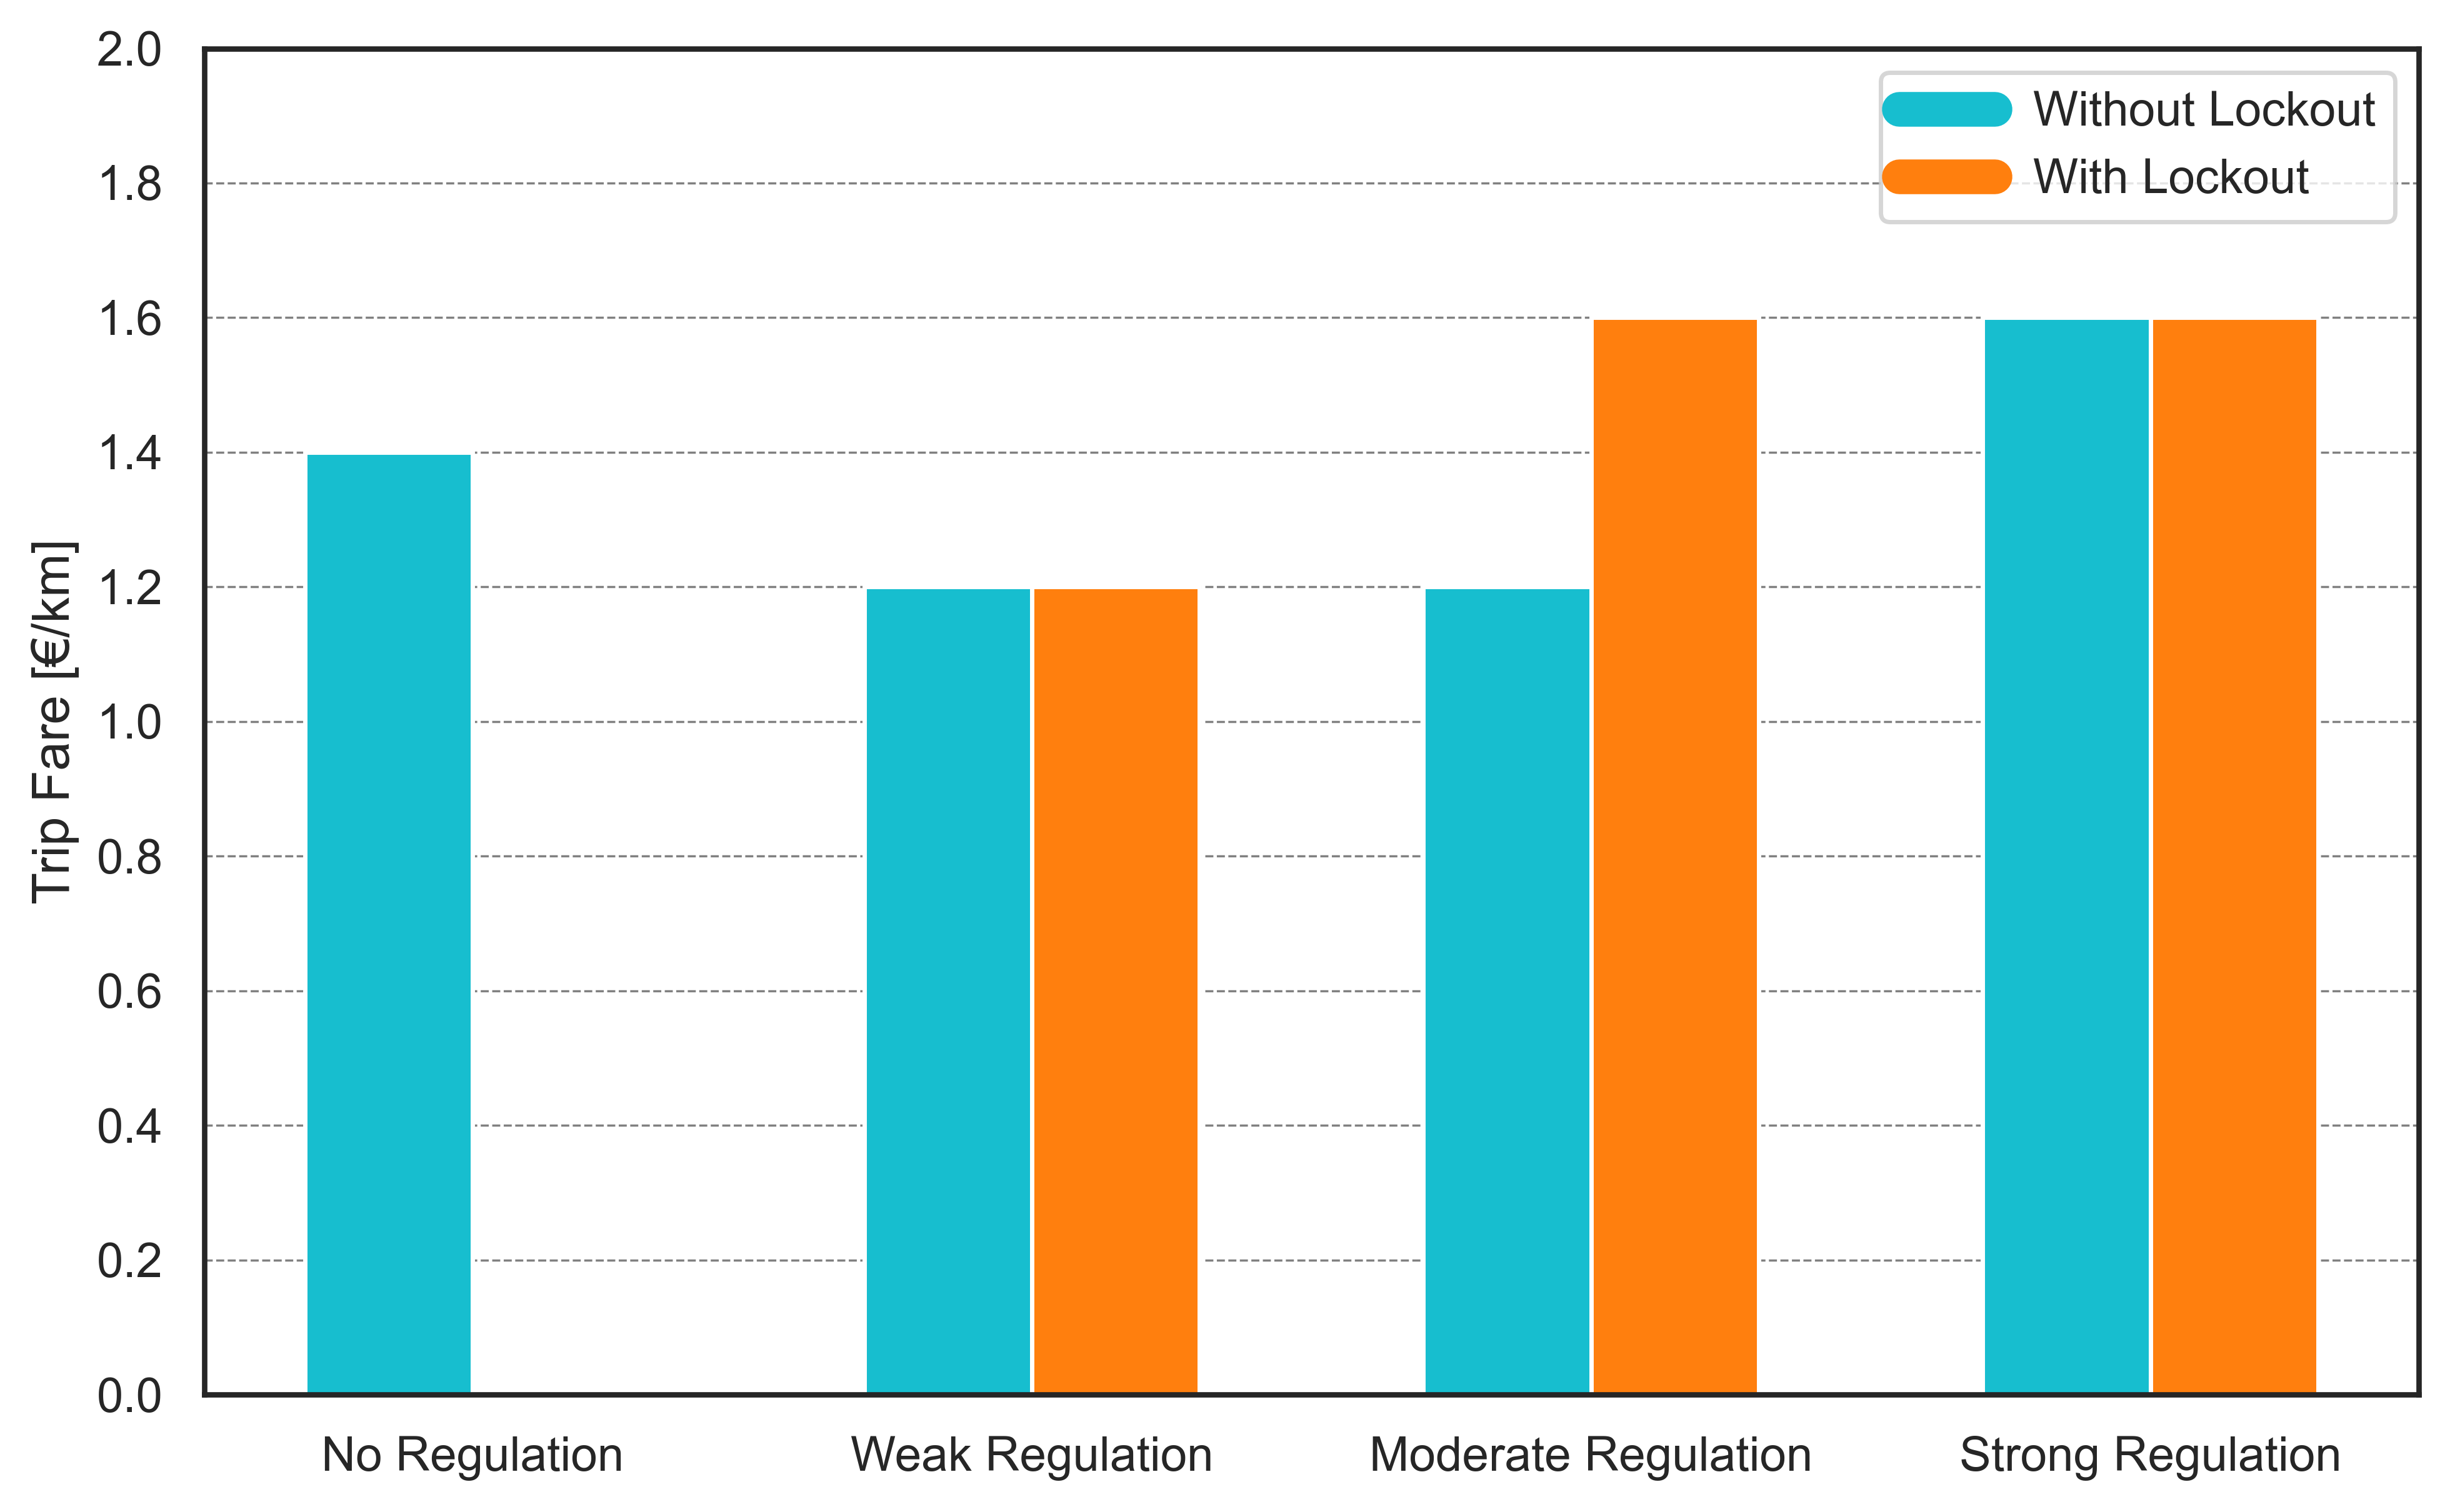

In [15]:
sns.set(rc={"figure.dpi": 500, 'savefig.dpi': 500})
sns.set(palette='tab10', font_scale=1.0)
sns.set_style('white')
fig, ax = plt.subplots(figsize=(8, 5))

c1 = 'C9'; c2 = 'C1'

groups = ['No Regulation', 'Weak Regulation', 'Moderate Regulation', 'Strong Regulation']
values_without_lockout = [1.4, 1.2, 1.2, 1.6]
values_with_lockout = [None, 1.2, 1.6, 1.6]  # None for the "No regulation" group where there is no "with lockout"

x = np.arange(len(groups))  # The label locations
width = 0.3  # Width of the bars

bars_without_lockout = ax.bar(x - width/2, values_without_lockout, width, label='Without Lockout', color=c1)

# Plot bars for "with lockout", skipping the first group
bars_with_lockout = [
    ax.bar(pos + width/2, value, width, color=c2, label='With Lockout' if i == 0 else "")
    for i, (pos, value) in enumerate(zip(x, values_with_lockout)) if value is not None
]

handles = [
    plt.Line2D([0], [0], color=c1, lw=8, label='Without Lockout'),
    plt.Line2D([0], [0], color=c2, lw=8, label='With Lockout')
]
ax.legend(handles=handles)
ax.set(xlabel='', ylabel='Trip Fare [€/km]', ylim=(0.0, 2.0))
ax.set_yticks(np.arange(0, 2.1, 0.2))
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(groups)

plt.tight_layout()
plt.savefig('Figs/1.2/P3_fig00.png')

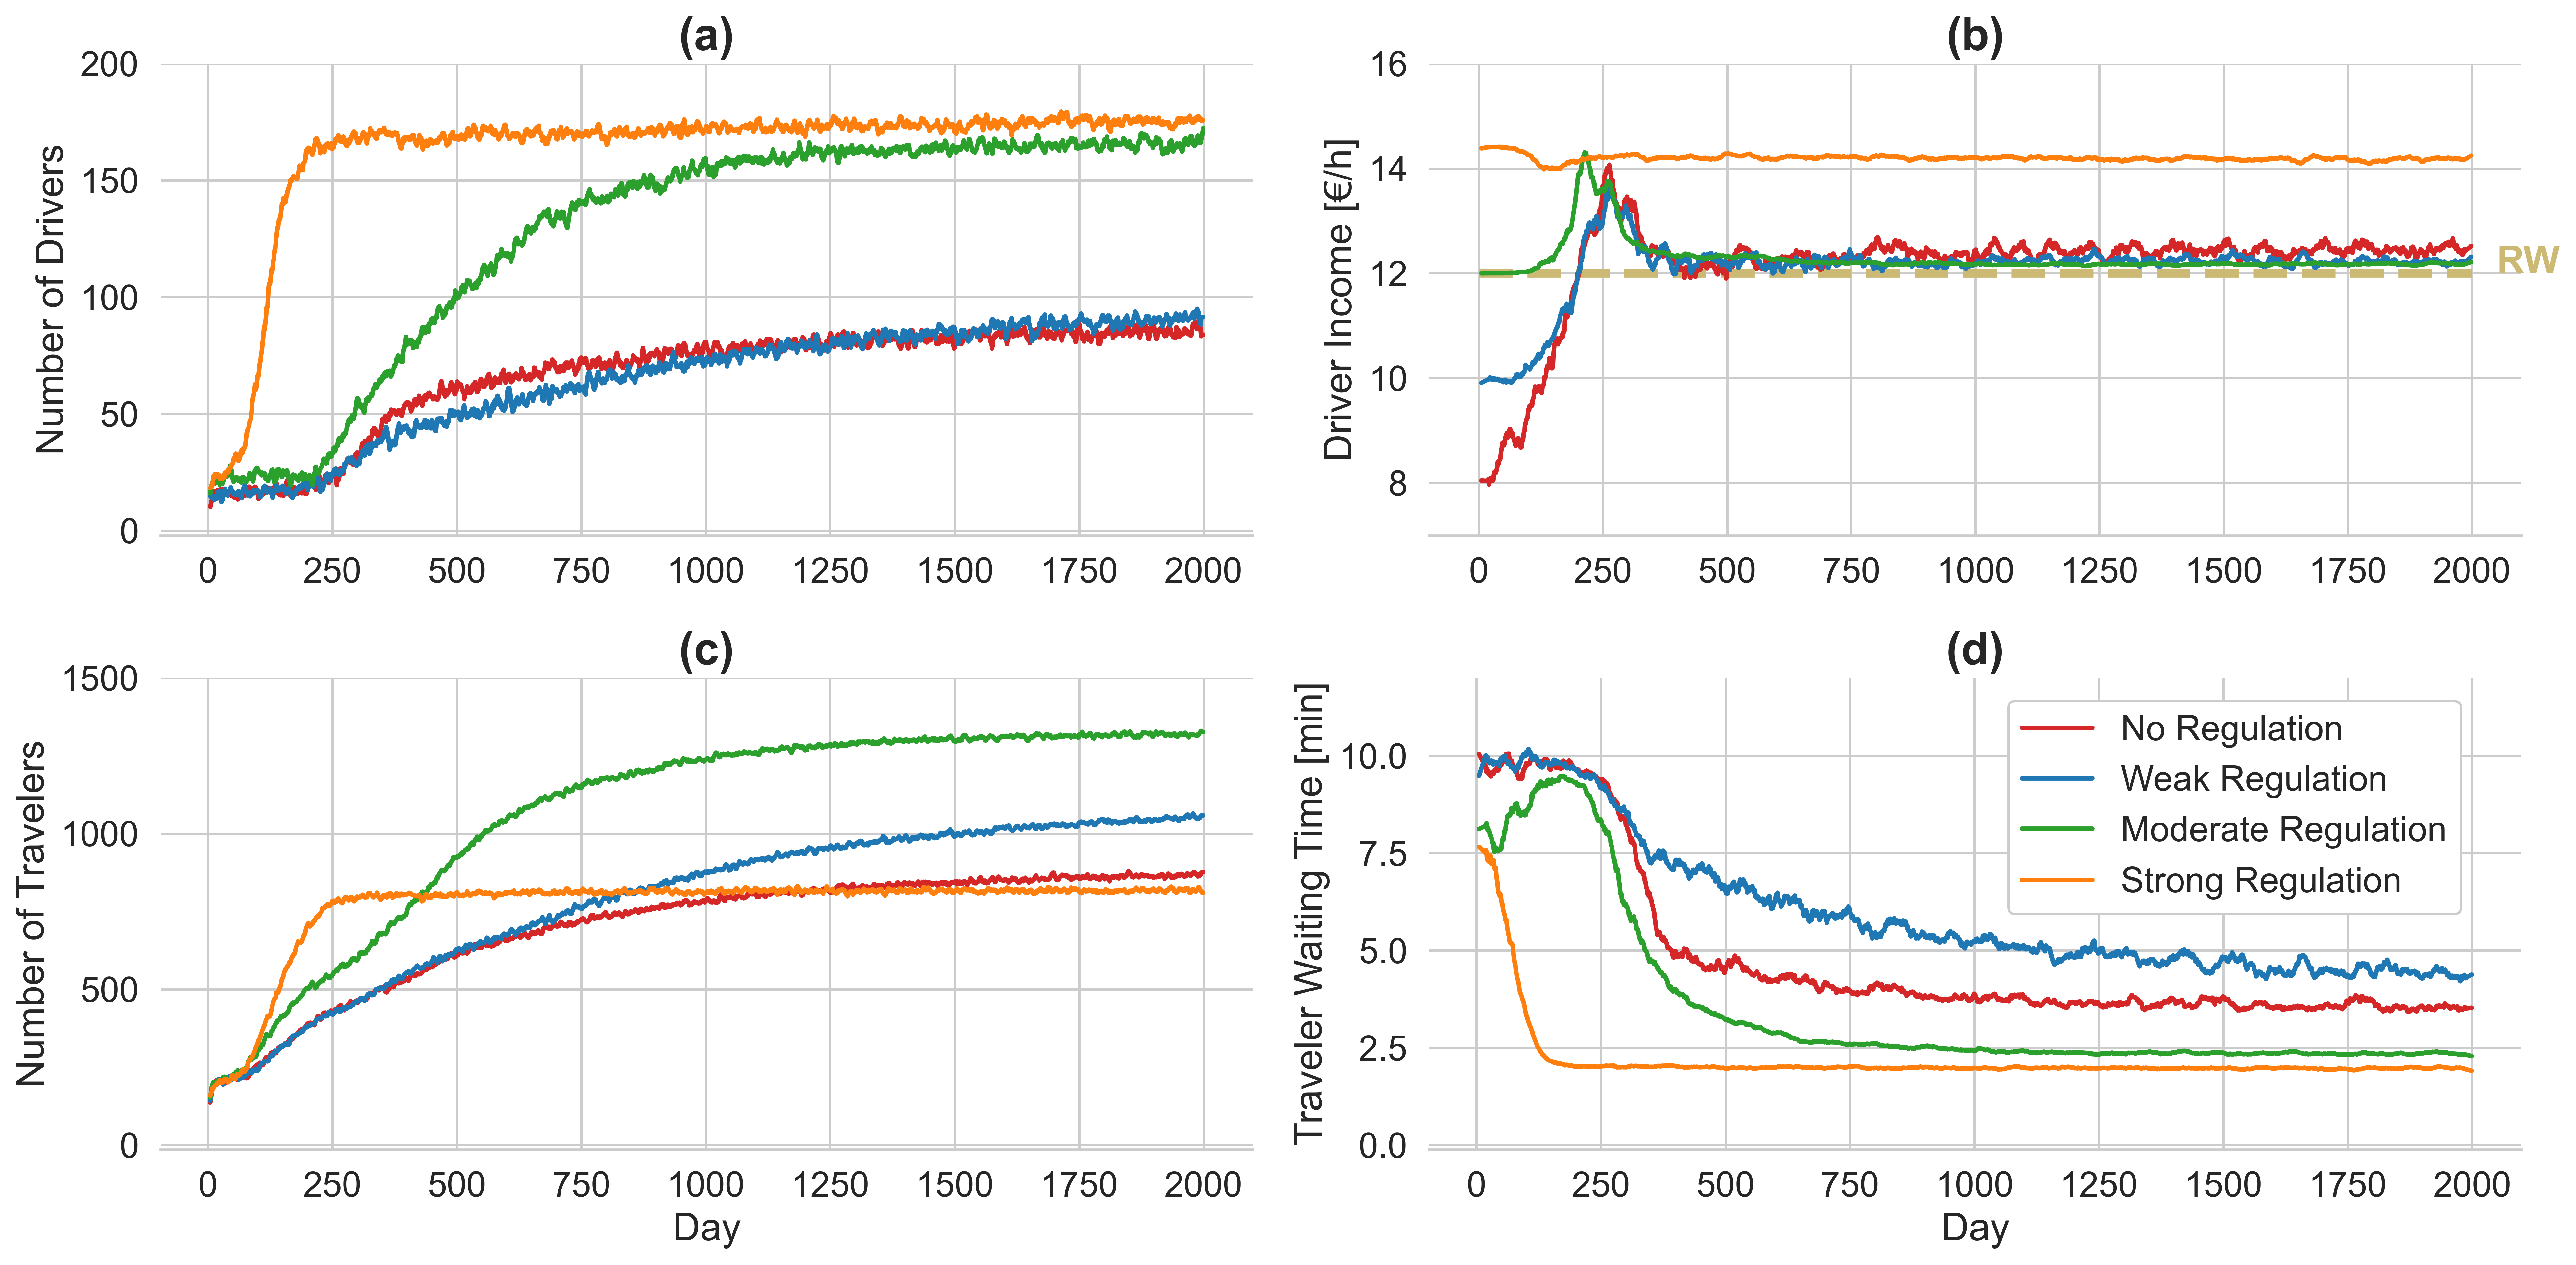

In [5]:
# With no lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1(d_nr.P1_OUT+d_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_wr.index, y=s_1(d_wr.P1_OUT+d_wr.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_mr.index, y=s_1(d_mr.P1_OUT+d_mr.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_sr.index, y=s_1(d_sr.P1_OUT+d_sr.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Number of Travelers', ylim = (-15, 1500))
ax[1][0].set_title('(c)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_2(((d_nr.P1_OUT*d_nr.P1_ACTUAL_WT)+(d_nr.P2_OUT*d_nr.P2_ACTUAL_WT))/(d_nr.P1_OUT+d_nr.P2_OUT)), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_wr.index, y=s_2(((d_wr.P1_OUT*d_wr.P1_ACTUAL_WT)+(d_wr.P2_OUT*d_wr.P2_ACTUAL_WT))/(d_wr.P1_OUT+d_wr.P2_OUT)), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_mr.index, y=s_2(((d_mr.P1_OUT*d_mr.P1_ACTUAL_WT)+(d_mr.P2_OUT*d_mr.P2_ACTUAL_WT))/(d_mr.P1_OUT+d_mr.P2_OUT)), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_sr.index, y=s_2(((d_sr.P1_OUT*d_sr.P1_ACTUAL_WT)+(d_sr.P2_OUT*d_sr.P2_ACTUAL_WT))/(d_sr.P1_OUT+d_sr.P2_OUT)), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Traveler Waiting Time [min]', ylim = (-0.12, 12))
ax[1][1].set_title('(d)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_1(s_nr.P1_OUT+s_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=s_wr.index, y=s_1(s_wr.P1_OUT+s_wr.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=s_mr.index, y=s_1(s_mr.P1_OUT+s_mr.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=s_sr.index, y=s_1(s_sr.P1_OUT+s_sr.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])
ax[0][0].legend().remove()

ax[0][0].set(xlabel='', ylabel='Number of Drivers', ylim = (-2, 200))
ax[0][0].set_title('(a)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_2((((s_nr.P1_OUT*s_nr.P1_ACTUAL_INC)+(s_nr.P2_OUT*s_nr.P2_ACTUAL_INC))/(s_nr.P1_OUT+s_nr.P2_OUT))/4), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=s_wr.index, y=s_2((((s_wr.P1_OUT*s_wr.P1_ACTUAL_INC)+(s_wr.P2_OUT*s_wr.P2_ACTUAL_INC))/(s_wr.P1_OUT+s_wr.P2_OUT))/4), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=s_mr.index, y=s_2((((s_mr.P1_OUT*s_mr.P1_ACTUAL_INC)+(s_mr.P2_OUT*s_mr.P2_ACTUAL_INC))/(s_mr.P1_OUT+s_mr.P2_OUT))/4), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=s_sr.index, y=s_2((((s_sr.P1_OUT*s_sr.P1_ACTUAL_INC)+(s_sr.P2_OUT*s_sr.P2_ACTUAL_INC))/(s_sr.P1_OUT+s_sr.P2_OUT))/4), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Driver Income [€/h]', ylim = (7, 16))
ax[0][1].set_title('(b)',fontweight='bold', loc='center',fontsize=20)

ax[0][1].hlines([12], 0, 2000, linestyles='dashed', colors='y', lw=4)
ax[0][1].annotate('RW', xy =(2050,12), fontweight='bold', color='y')  

#-------------------------------------------------

ax[1][1].legend(frameon=True,framealpha=1, loc=(0.53,0.5))
plt.tight_layout()
# plt.savefig('Figs/1.3/P3_fig2.png')

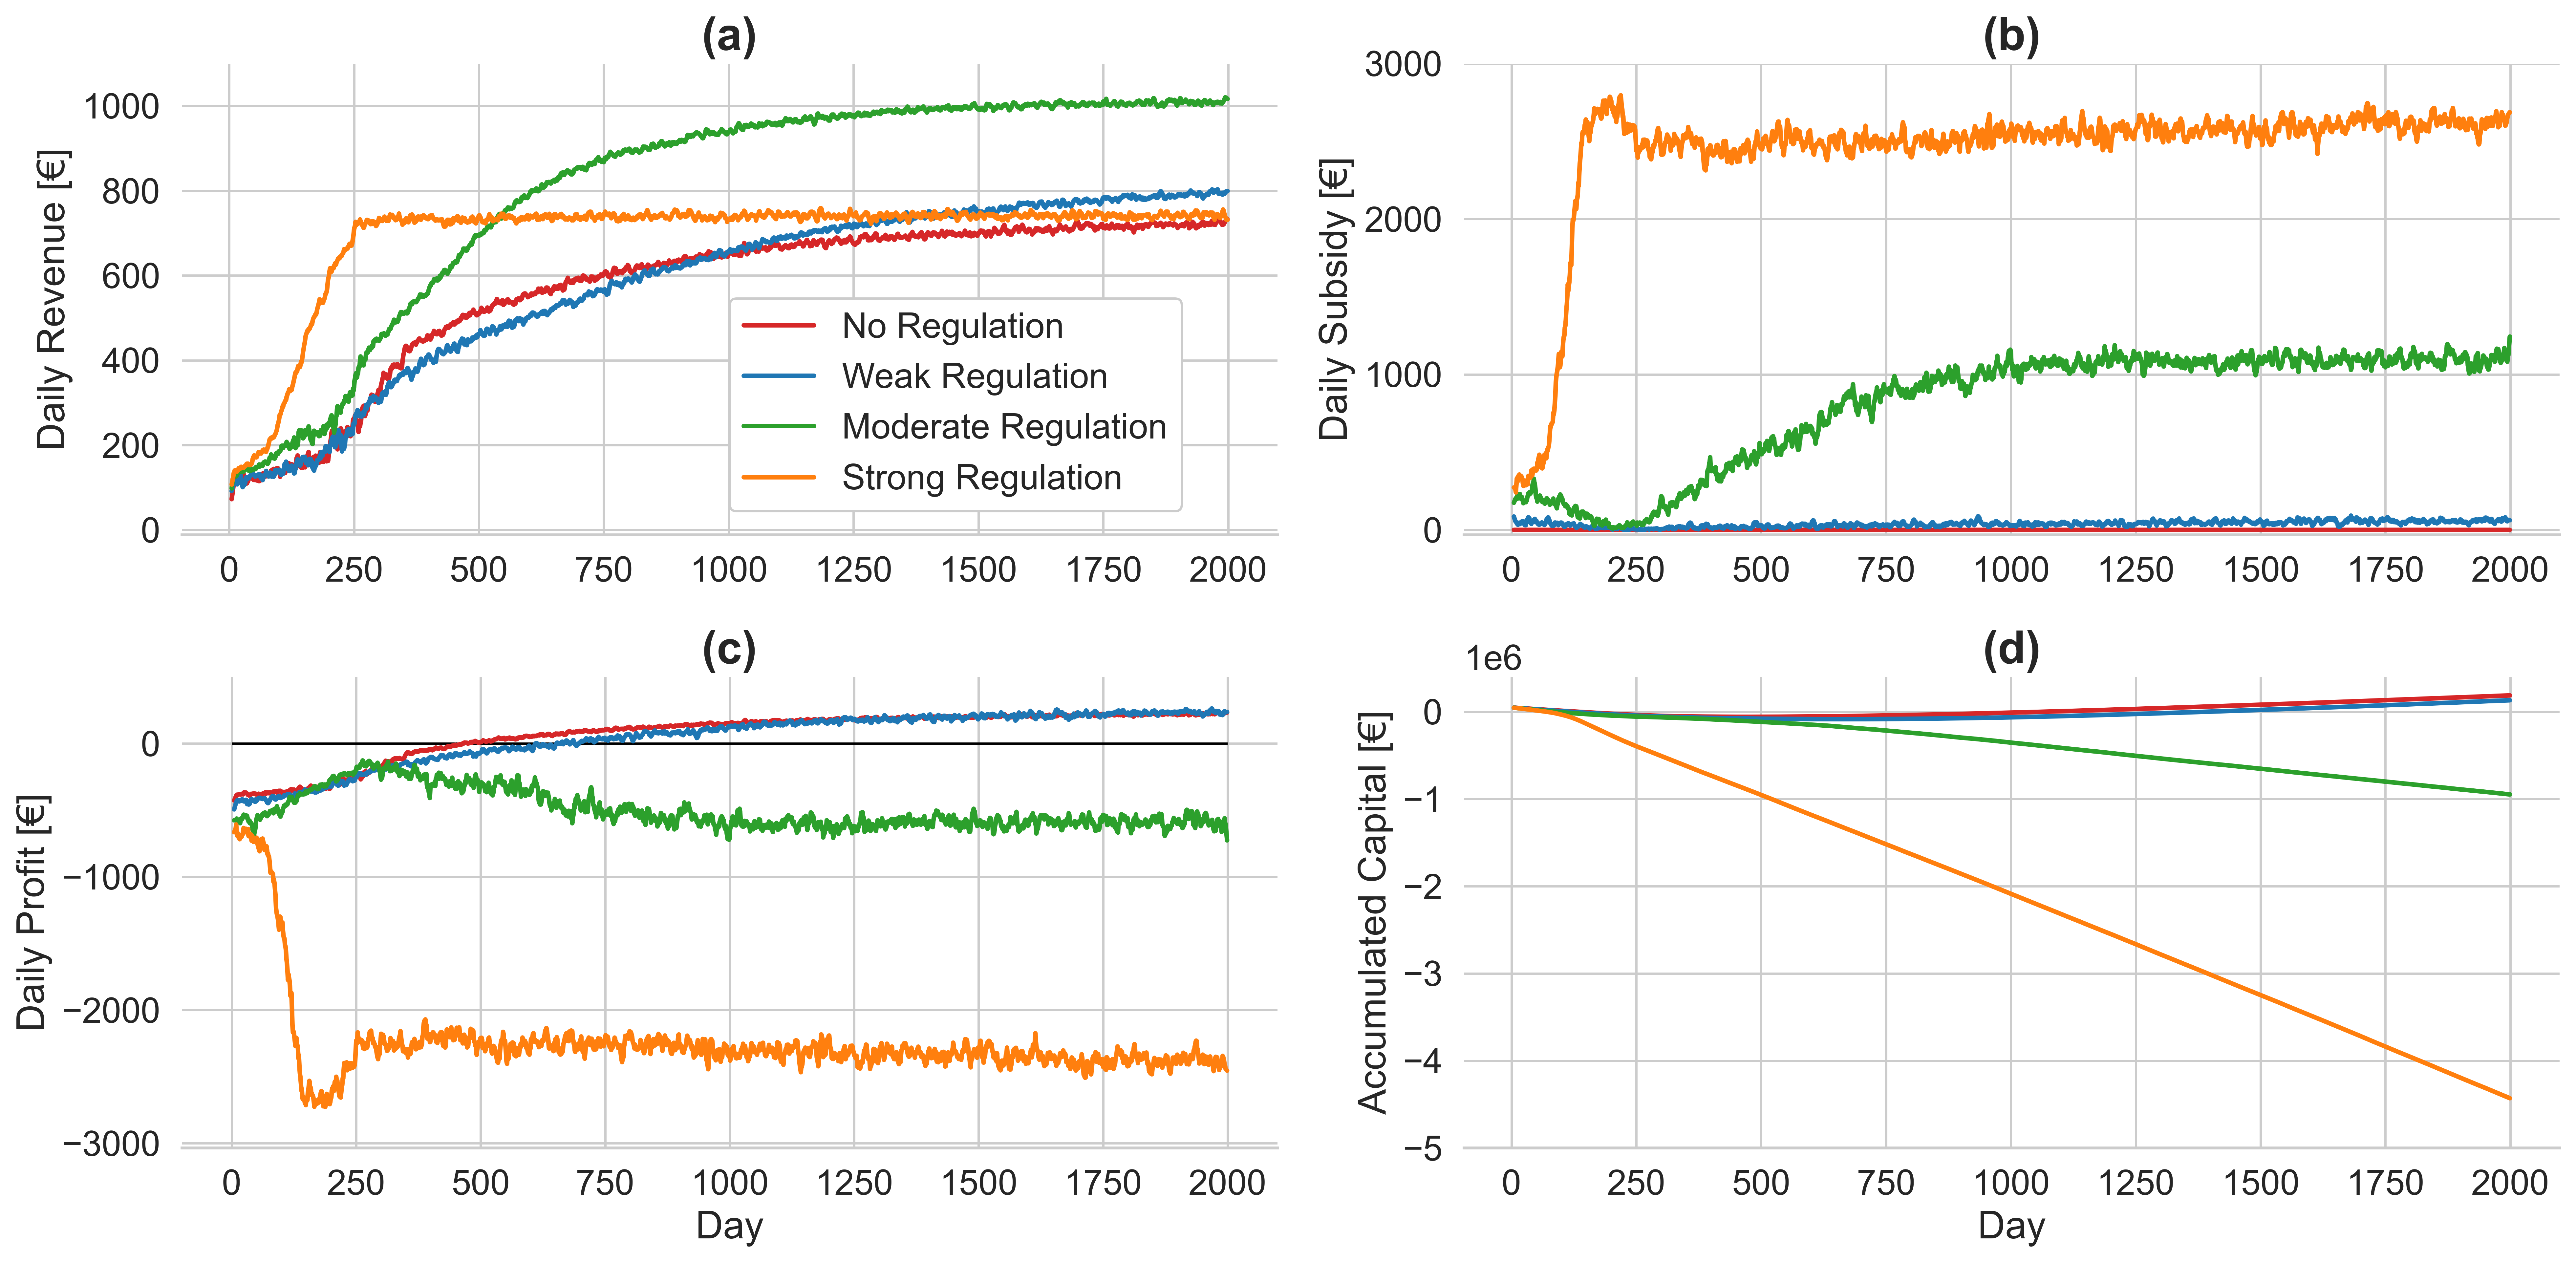

In [12]:
# With no lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_revenue+d_nr.P2_revenue)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_revenue+d_wr.P2_revenue)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_revenue+d_mr.P2_revenue)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_revenue+d_sr.P2_revenue)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])

ax[0][0].set(xlabel='', ylabel='Daily Revenue [€]', ylim = (-11, 1100))
ax[0][0].set_title('(a)',fontweight='bold', loc='center',fontsize=20)
ax[0][0].legend().remove()

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_min_wage_sub+d_nr.P2_min_wage_sub)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_min_wage_sub+d_wr.P2_min_wage_sub)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_min_wage_sub+d_mr.P2_min_wage_sub)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_min_wage_sub+d_sr.P2_min_wage_sub)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Daily Subsidy [€]', ylim = (-30, 3000))
ax[0][1].set_title('(b)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_profit+d_nr.P2_profit)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_profit+d_wr.P2_profit)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_profit+d_mr.P2_profit)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_profit+d_sr.P2_profit)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Daily Profit [€]', ylim = (-3035, 500))
ax[1][0].set_title('(c)',fontweight='bold', loc='center',fontsize=20)

ax[1][0].hlines([0], 0, 2000, linestyles='solid', colors='black', lw=1)

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_remaining_capital+d_nr.P2_remaining_capital)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_remaining_capital+d_wr.P2_remaining_capital)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_remaining_capital+d_mr.P2_remaining_capital)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_remaining_capital+d_sr.P2_remaining_capital)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

# ax[1][1].set(xlabel='Day', ylabel='Accumulated Capital [€]', ylim = (-5025000, 500000))
ax[1][1].set(xlabel='Day', ylabel='Accumulated Capital [€]', ylim = (-5000000, 400000))
ax[1][1].set_title('(d)',fontweight='bold', loc='center',fontsize=20)
# ax[1][1].set_yscale('symlog', linthresh=1e-)
#-------------------------------------------------

ax[0][0].legend(frameon=True,framealpha=1, loc=(0.5,0.05))
plt.tight_layout()
plt.savefig('Figs/1.3/P3_fig3.png')

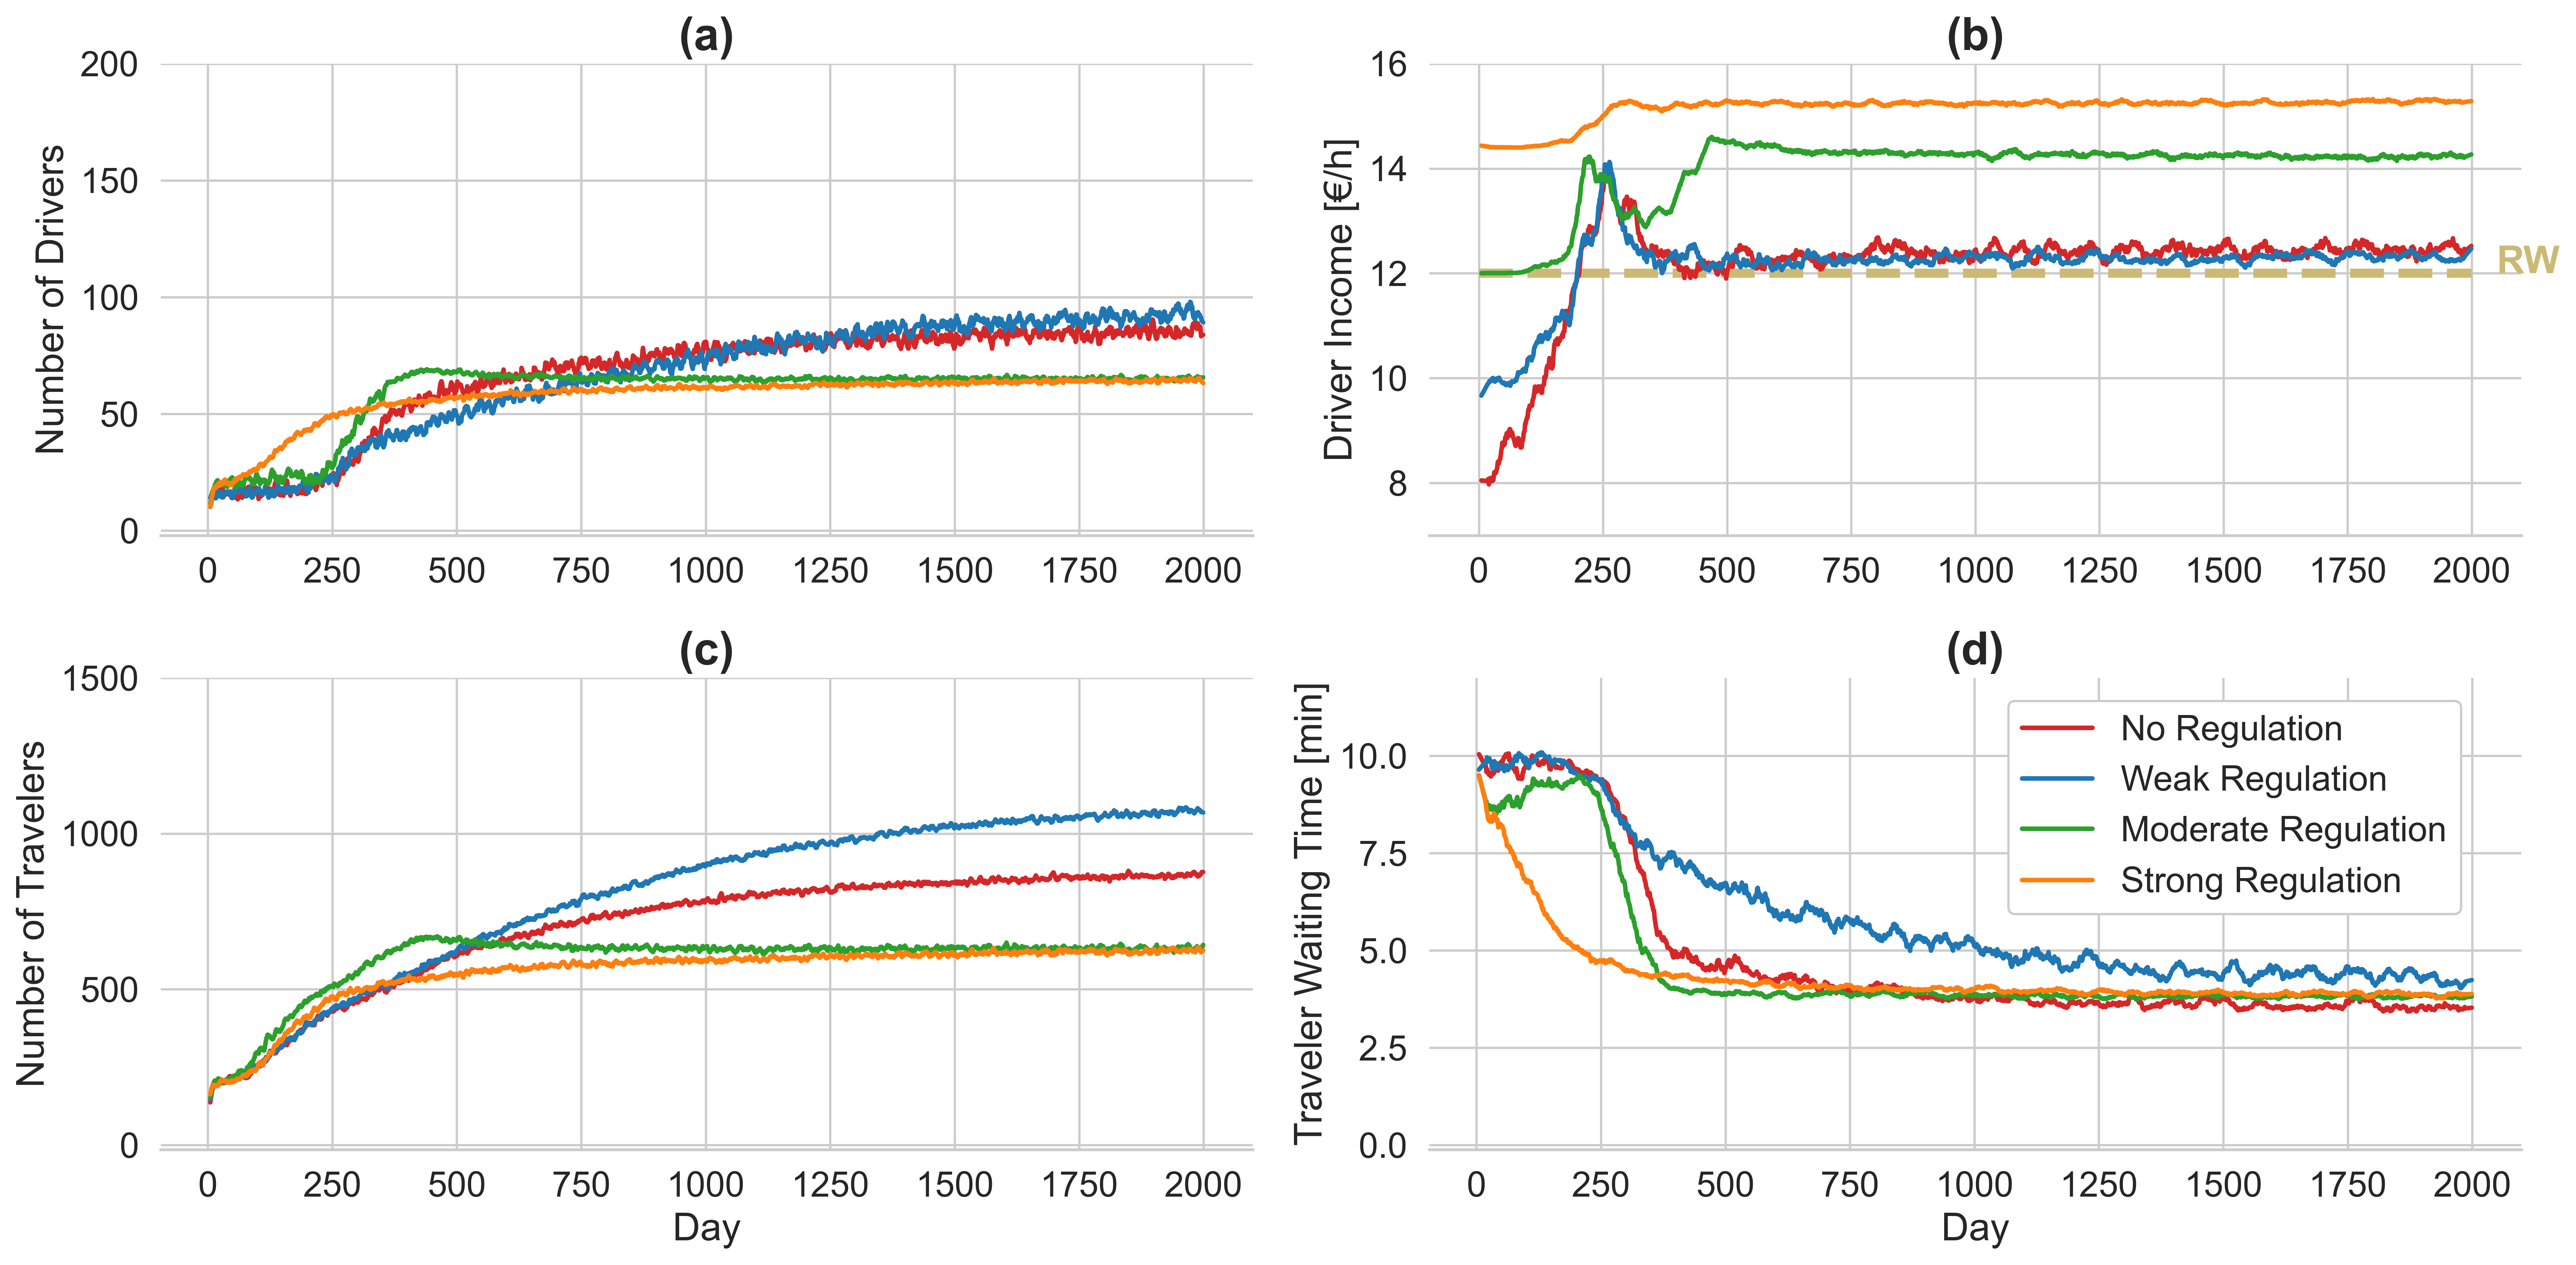

In [38]:
# With lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1(d_nr.P1_OUT+d_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_wrl.index, y=s_1(d_wrl.P1_OUT+d_wrl.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_mrl.index, y=s_1(d_mrl.P1_OUT+d_mrl.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_srl.index, y=s_1(d_srl.P1_OUT+d_srl.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Number of Travelers', ylim = (-15, 1500))
ax[1][0].set_title('(c)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_2(((d_nr.P1_OUT*d_nr.P1_ACTUAL_WT)+(d_nr.P2_OUT*d_nr.P2_ACTUAL_WT))/(d_nr.P1_OUT+d_nr.P2_OUT)), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_wrl.index, y=s_2(((d_wrl.P1_OUT*d_wrl.P1_ACTUAL_WT)+(d_wrl.P2_OUT*d_wrl.P2_ACTUAL_WT))/(d_wrl.P1_OUT+d_wrl.P2_OUT)), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_mrl.index, y=s_2(((d_mrl.P1_OUT*d_mrl.P1_ACTUAL_WT)+(d_mrl.P2_OUT*d_mrl.P2_ACTUAL_WT))/(d_mrl.P1_OUT+d_mrl.P2_OUT)), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_srl.index, y=s_2(((d_srl.P1_OUT*d_srl.P1_ACTUAL_WT)+(d_srl.P2_OUT*d_srl.P2_ACTUAL_WT))/(d_srl.P1_OUT+d_srl.P2_OUT)), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Traveler Waiting Time [min]', ylim = (-0.12, 12))
ax[1][1].set_title('(d)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_1(s_nr.P1_OUT+s_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=s_wrl.index, y=s_1(s_wrl.P1_OUT+s_wrl.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=s_mrl.index, y=s_1(s_mrl.P1_OUT+s_mrl.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=s_srl.index, y=s_1(s_srl.P1_OUT+s_srl.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])
ax[0][0].legend().remove()

ax[0][0].set(xlabel='', ylabel='Number of Drivers', ylim = (-2, 200))
ax[0][0].set_title('(a)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_2((((s_nr.P1_OUT*s_nr.P1_ACTUAL_INC)+(s_nr.P2_OUT*s_nr.P2_ACTUAL_INC))/(s_nr.P1_OUT+s_nr.P2_OUT))/4), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=s_wrl.index, y=s_2((((s_wrl.P1_OUT*s_wrl.P1_ACTUAL_INC)+(s_wrl.P2_OUT*s_wrl.P2_ACTUAL_INC))/(s_wrl.P1_OUT+s_wrl.P2_OUT))/4), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=s_mrl.index, y=s_2((((s_mrl.P1_OUT*s_mrl.P1_ACTUAL_INC)+(s_mrl.P2_OUT*s_mrl.P2_ACTUAL_INC))/(s_mrl.P1_OUT+s_mrl.P2_OUT))/4), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=s_srl.index, y=s_2((((s_srl.P1_OUT*s_srl.P1_ACTUAL_INC)+(s_srl.P2_OUT*s_srl.P2_ACTUAL_INC))/(s_srl.P1_OUT+s_srl.P2_OUT))/4), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Driver Income [€/h]', ylim = (7, 16))
ax[0][1].set_title('(b)',fontweight='bold', loc='center',fontsize=20)

ax[0][1].hlines([12], 0, 2000, linestyles='dashed', colors='y', lw=4)
ax[0][1].annotate('RW', xy =(2050,12), fontweight='bold', color='y') 

#-------------------------------------------------

ax[1][1].legend(frameon=True,framealpha=1, loc=(0.53,0.5))
plt.tight_layout()
plt.savefig('Figs/1.3/P3_fig4.png')

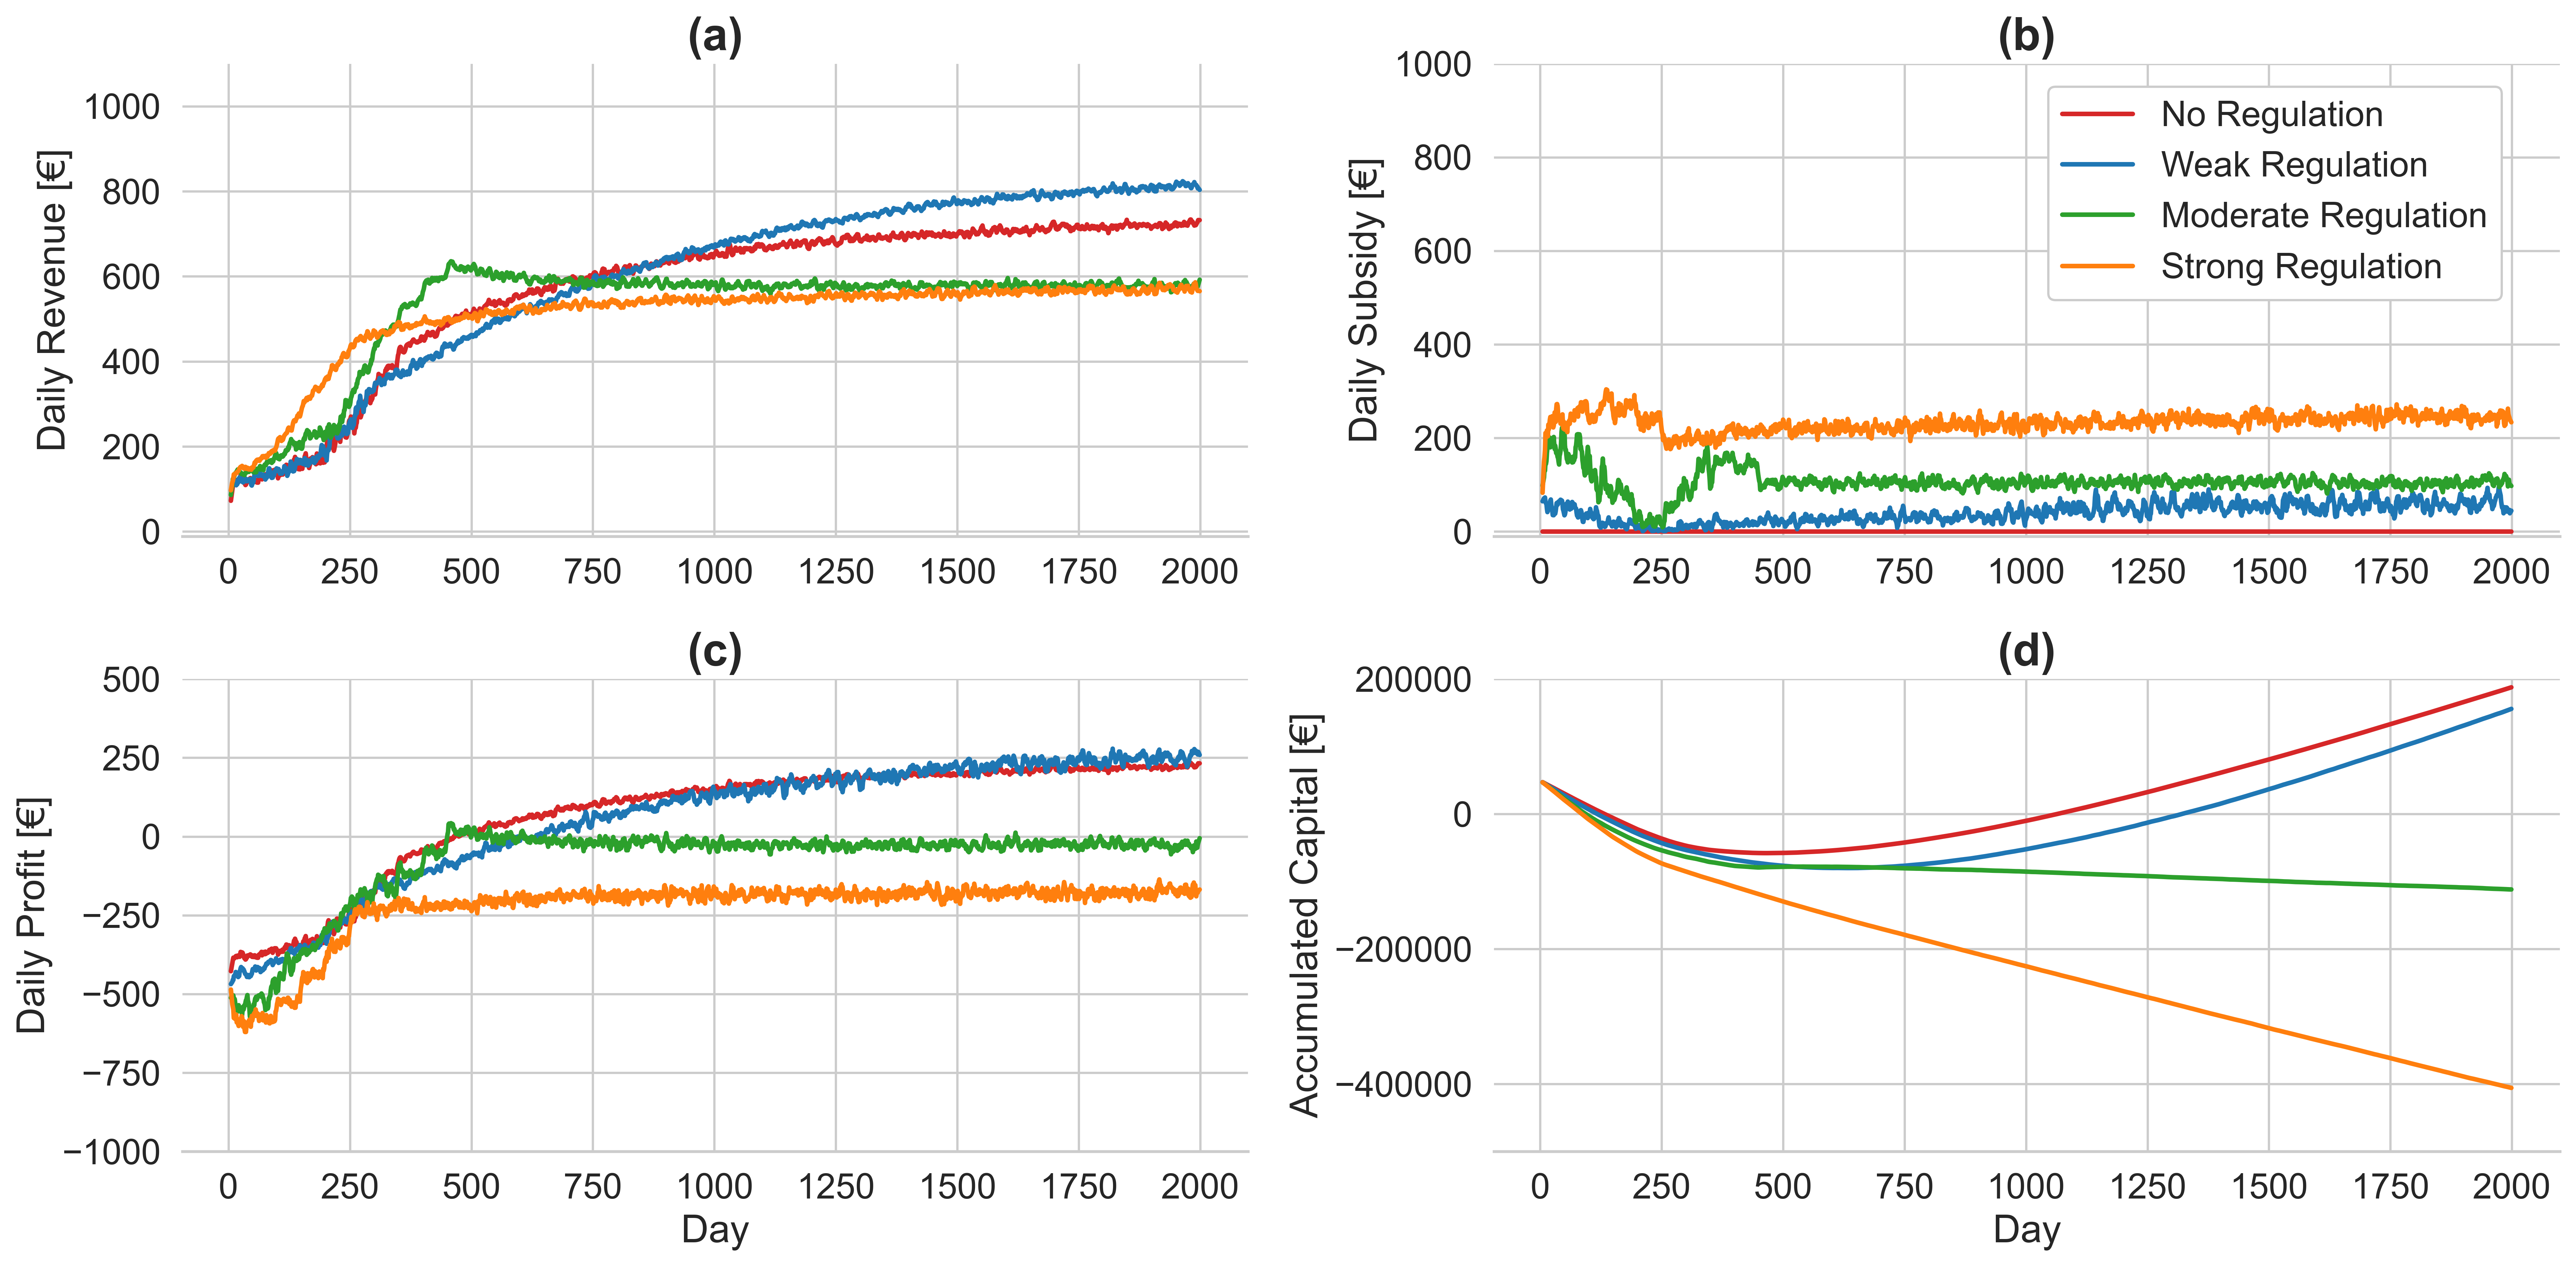

In [ ]:
# With lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_revenue+d_nr.P2_revenue)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_revenue+d_wrl.P2_revenue)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_revenue+d_mrl.P2_revenue)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_revenue+d_srl.P2_revenue)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])

ax[0][0].set(xlabel='', ylabel='Daily Revenue [€]', ylim = (-11, 1100))
ax[0][0].set_title('(a)',fontweight='bold', loc='center',fontsize=20)
ax[0][0].legend().remove()

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_min_wage_sub+d_nr.P2_min_wage_sub)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_min_wage_sub+d_wrl.P2_min_wage_sub)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_min_wage_sub+d_mrl.P2_min_wage_sub)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_min_wage_sub+d_srl.P2_min_wage_sub)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Daily Subsidy [€]', ylim = (-10, 1000))
ax[0][1].set_title('(b)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_profit+d_nr.P2_profit)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_profit+d_wrl.P2_profit)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_profit+d_mrl.P2_profit)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_profit+d_srl.P2_profit)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Daily Profit [€]', ylim = (-1000, 500))
ax[1][0].set_title('(c)',fontweight='bold', loc='center',fontsize=20)

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_remaining_capital+d_nr.P2_remaining_capital)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_remaining_capital+d_wrl.P2_remaining_capital)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_remaining_capital+d_mrl.P2_remaining_capital)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_remaining_capital+d_srl.P2_remaining_capital)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Accumulated Capital [€]', ylim = (-500000, 500000))
ax[1][1].set_title('(d)',fontweight='bold', loc='center',fontsize=20)

#-------------------------------------------------

ax[0][1].legend(frameon=True,framealpha=1, loc=(0.52,0.5))
plt.tight_layout()
plt.savefig('Figs/1.3/P3_fig5.png')

In [76]:
s_violin = pd.DataFrame(columns=['Driver Income [€]','Regulation', 'Strategy'])

df_list = [dist_s, dist_swr, dist_swrl, dist_smr, dist_smrl, dist_ssr, dist_ssrl]
reg = ['No Regulation', 'Weak Regulation', 'Weak Regulation', 'Moderate Regulation', 'Moderate Regulation', 'Strong Regulation', 'Strong Regulation']
ls = ['Without Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy']

for i, df in enumerate(df_list): 
    
    df = df[['DAY_1999']]
    df = df[df.DAY_1999 != 0]
    df.rename(columns={'DAY_1999': 'Driver Income [€]'}, inplace=True)
    df['Regulation'] = reg[i]
    df['Strategy'] = ls[i]
    
    s_violin = pd.concat([s_violin, df], ignore_index=True)
s_violin['Driver Income [€]'] = s_violin['Driver Income [€]']/4
#-------------------------------------------------------------------------------------------

d_violin = pd.DataFrame(columns=['Traveler Waiting Time [min]','Regulation', 'Strategy'])

df_list = [dist_d, dist_dwr, dist_dwrl, dist_dmr, dist_dmrl, dist_dsr, dist_dsrl]
reg = ['No Regulation', 'Weak Regulation', 'Weak Regulation', 'Moderate Regulation', 'Moderate Regulation', 'Strong Regulation', 'Strong Regulation']
ls = ['Without Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy']

for i, df in enumerate(df_list): 
    
    df = df[['DAY_1998']]
    df = df[df.DAY_1998 != 0]
    df.rename(columns={'DAY_1998': 'Traveler Waiting Time [min]'}, inplace=True)
    df['Regulation'] = reg[i]
    df['Strategy'] = ls[i]
    
    d_violin = pd.concat([d_violin, df], ignore_index=True)

In [99]:
df = d_violin
df = df[(df.Regulation=='Weak Regulation') & (df.Strategy=='With Lockout Strategy')]

# set(df['Driver Income [€]'])
# df[df['Driver Income [€]']==14.4].count()
# df['Traveler Waiting Time [min]'].mean()
df['Traveler Waiting Time [min]'].mean()

3.6707051282051286

In [157]:
nrows=2,

53.96825396825397

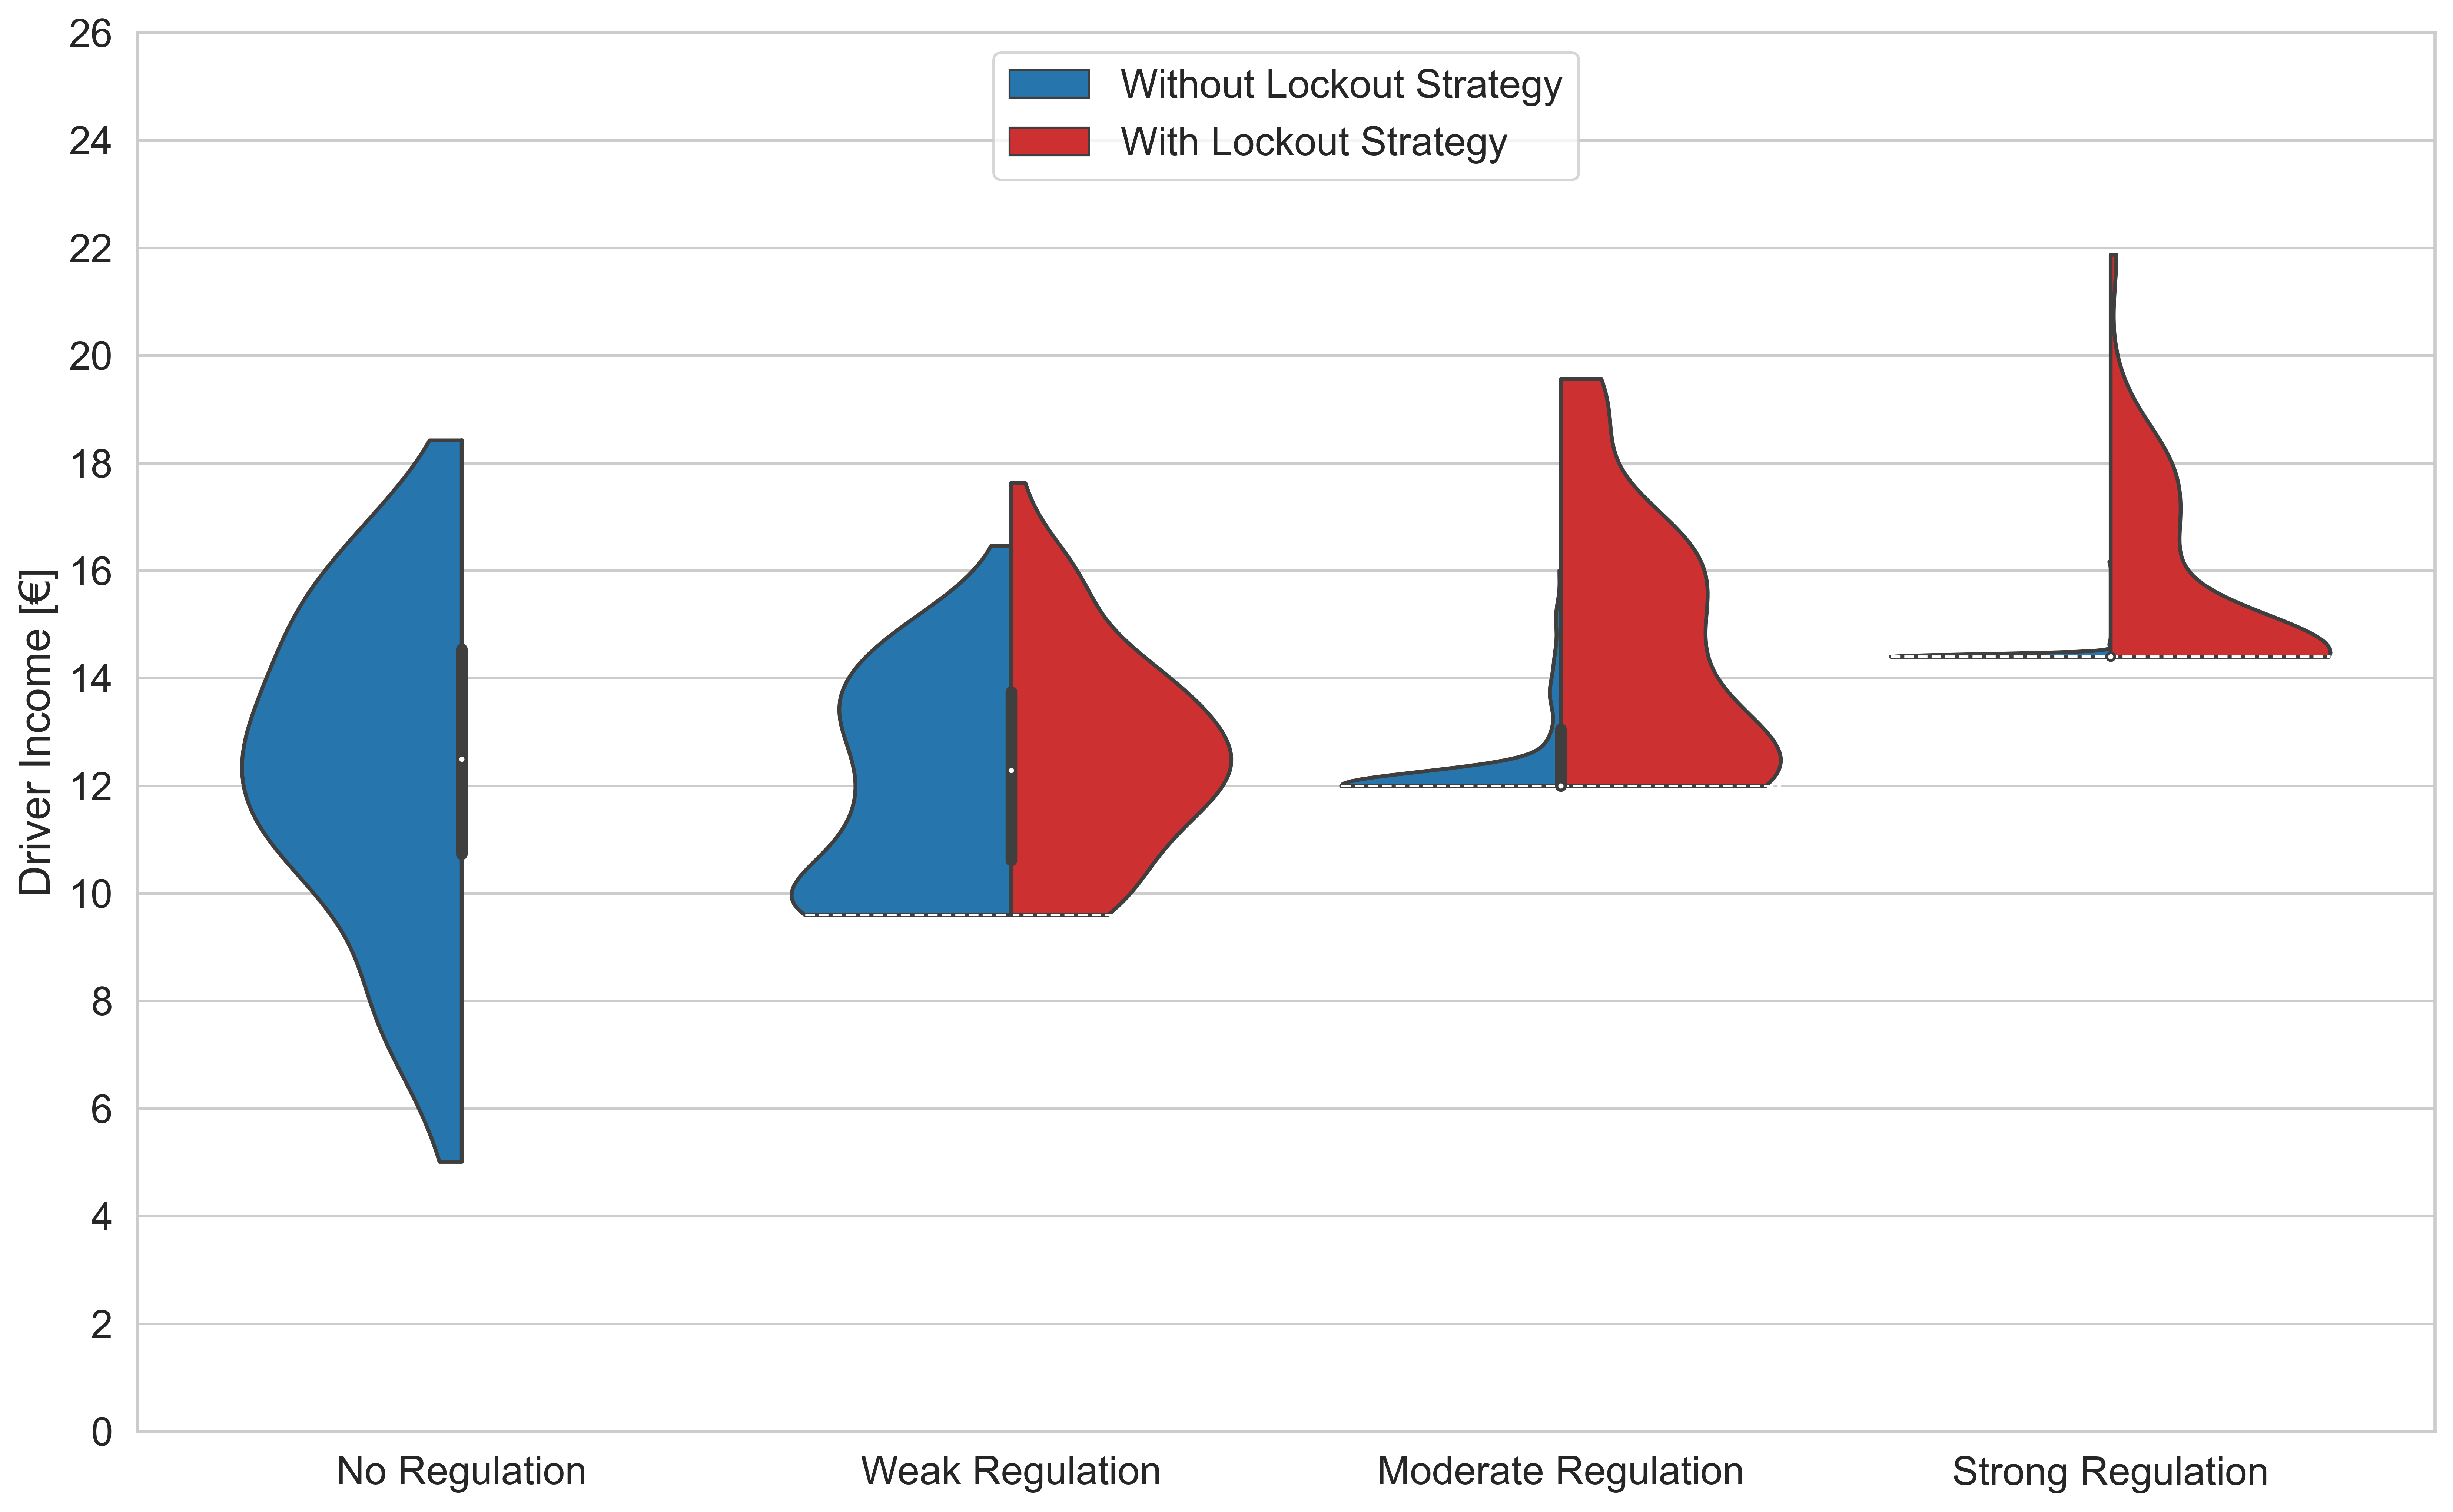

In [80]:
sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)
sns.set_style('whitegrid')


fig, ax = plt.subplots(figsize=(16, 10))
sns.violinplot(x='Regulation', y='Driver Income [€]', hue='Strategy', data=s_violin, saturation=0.9, split=True, inner="box",
               palette={'Without Lockout Strategy': 'C0', 'With Lockout Strategy': 'C3'}, scale='width', cut=0)  # Different colors for each group

yy = 26
ax.set(ylim=(0,yy))
plt.yticks(range(0, yy+1, 2))
plt.legend(loc='upper center')
plt.xlabel('')

horizontal_lines = {9.6: 1, 12: 2, 14.4: 3}
d = 0.4
for y, x in horizontal_lines.items():
    ax.hlines(y=y, xmin=x-d , xmax=x +d, color='white', linestyle='dashed', linewidth=1)

# plt.savefig('Figs/1.3/P3_fig6x2.png')

In [31]:
d_violin = pd.DataFrame(columns=['Traveler Waiting Time [min]','Regulation', 'Strategy'])

df_list = [dist_d, dist_dwr, dist_dwrl, dist_dmr, dist_dmrl, dist_dsr, dist_dsrl]
reg = ['No Regulation', 'Weak Regulation', 'Weak Regulation', 'Moderate Regulation', 'Moderate Regulation', 'Strong Regulation', 'Strong Regulation']
ls = ['Without Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy', 'Without Lockout Strategy', 'With Lockout Strategy']

for i, df in enumerate(df_list): 
    
    df = df[['DAY_1995']]
    df = df[df.DAY_1995 != 0]
    df.rename(columns={'DAY_1995': 'Traveler Waiting Time [min]'}, inplace=True)
    df['Regulation'] = reg[i]
    df['Strategy'] = ls[i]
    
    d_violin = pd.concat([d_violin, df], ignore_index=True)

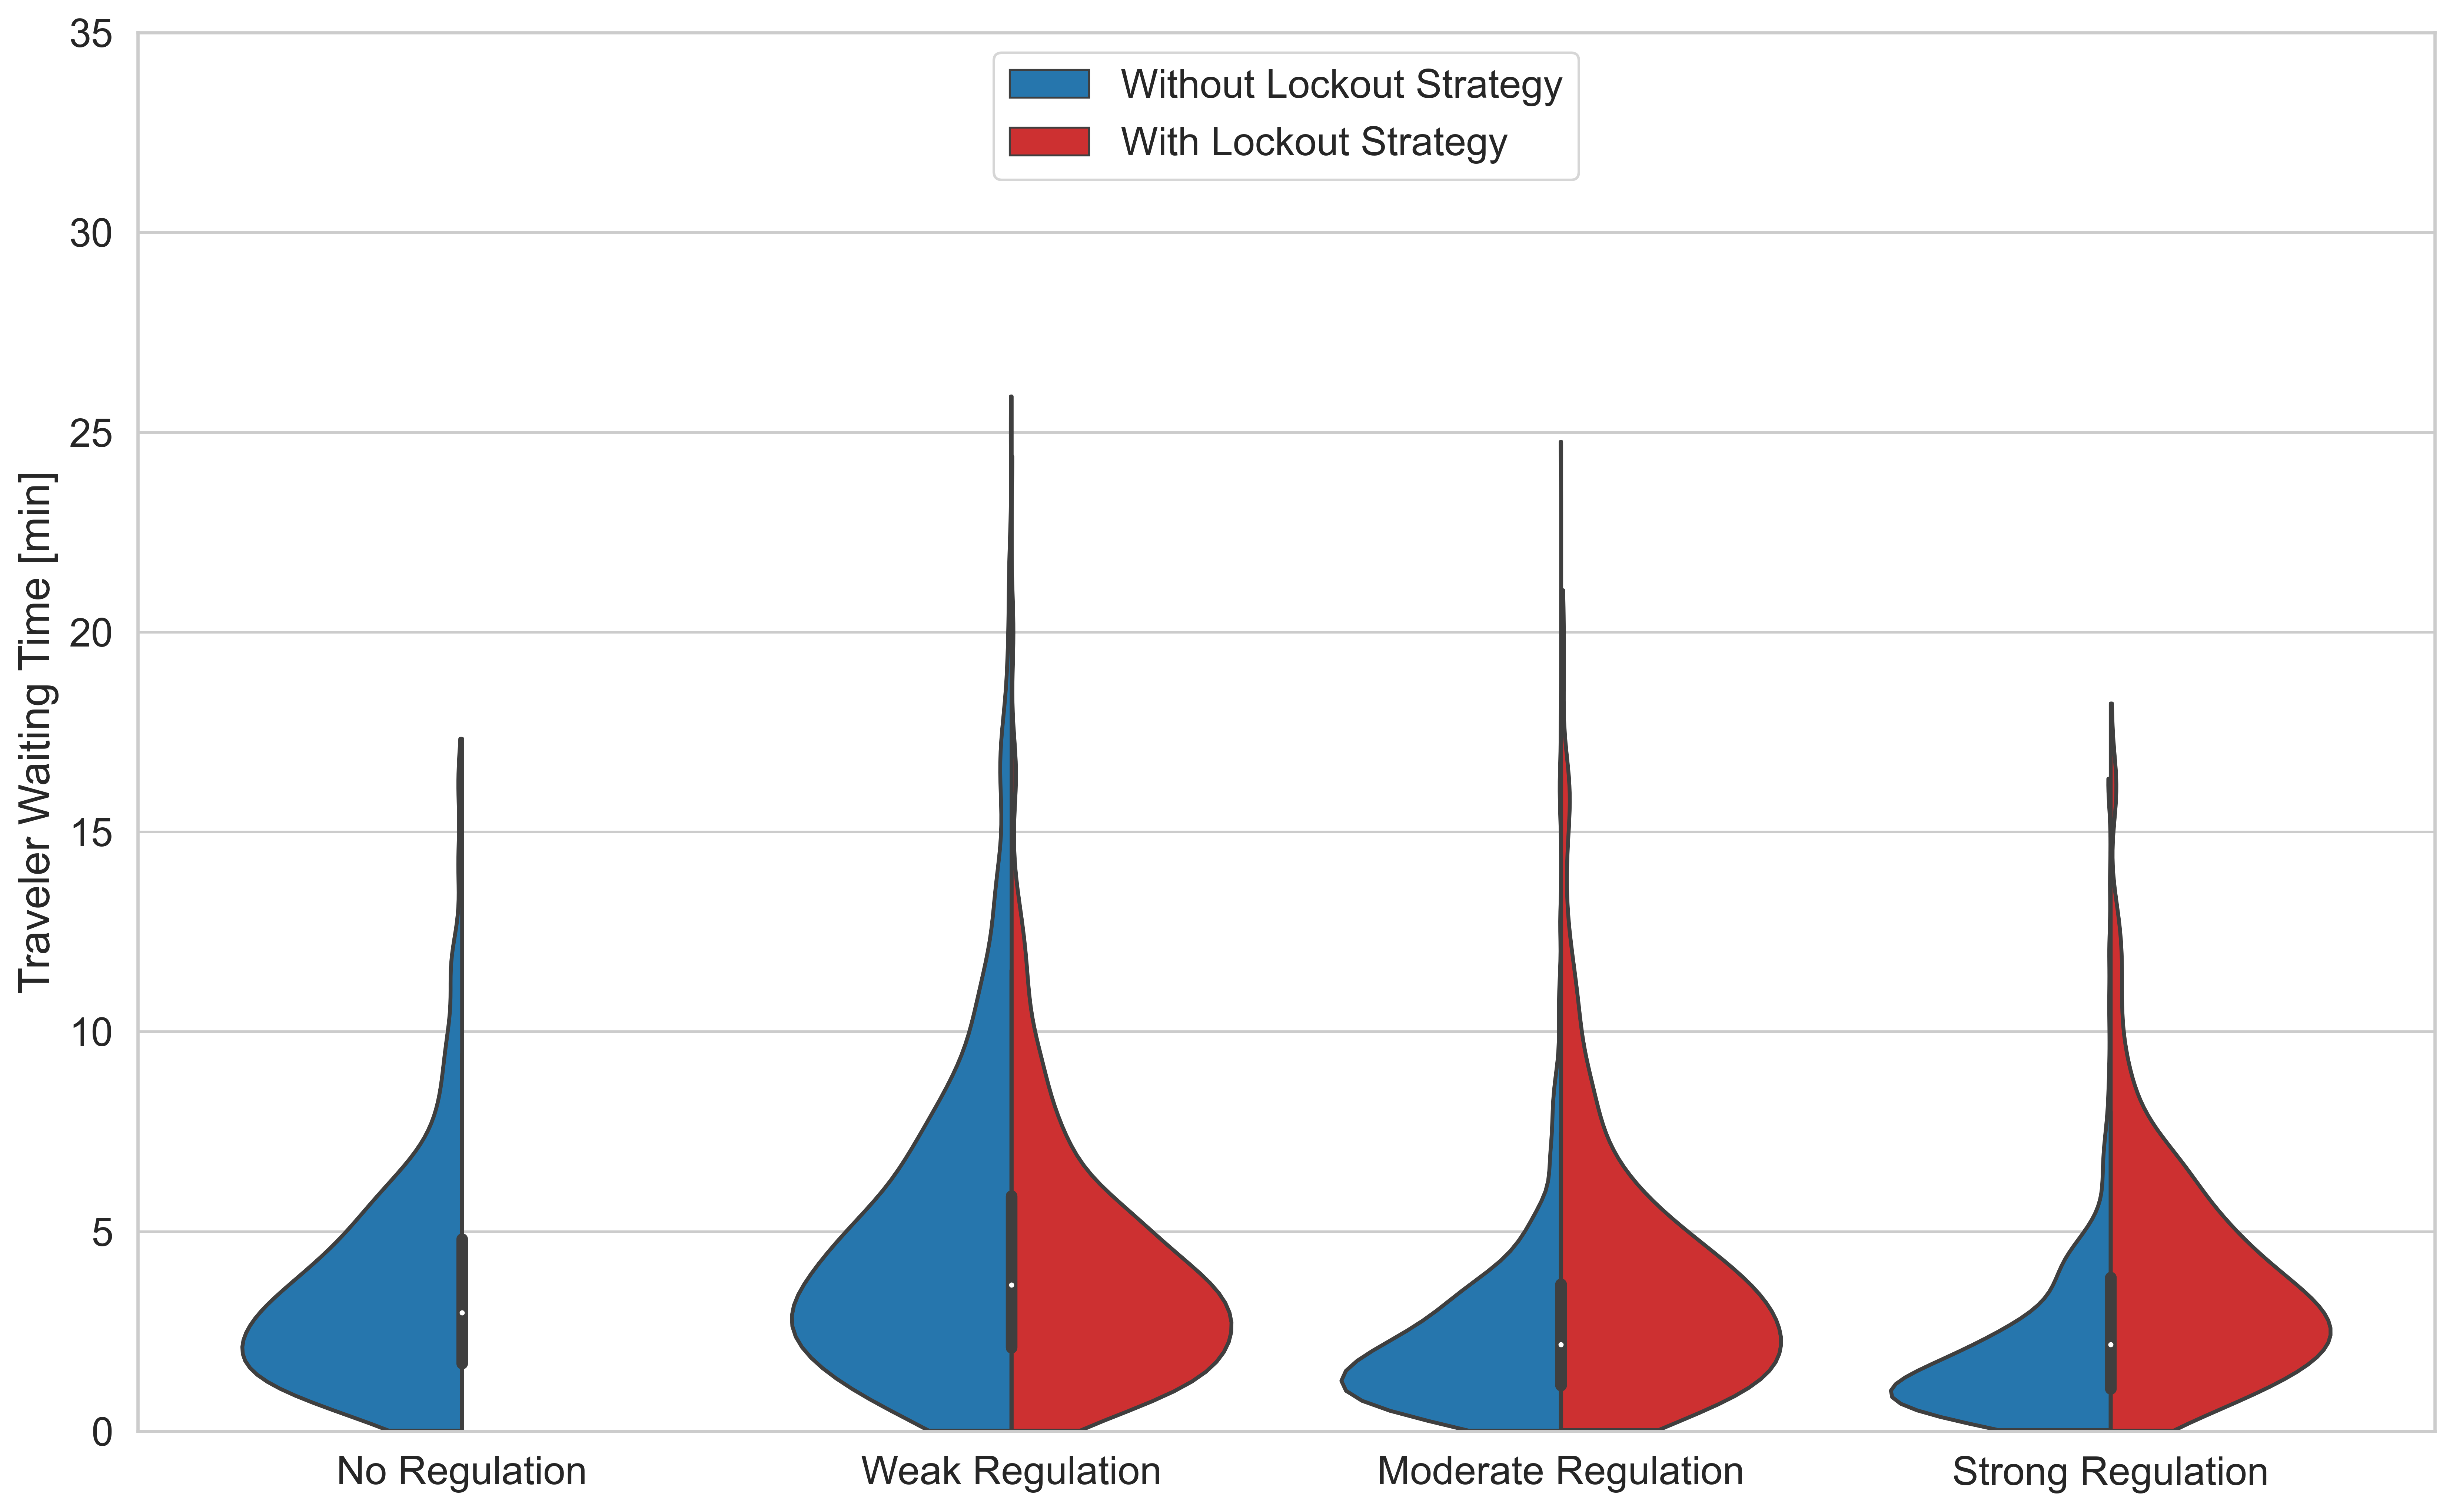

In [32]:
sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(16, 10))
sns.violinplot(x='Regulation', y='Traveler Waiting Time [min]', hue='Strategy', data=d_violin, saturation=0.9, split=True, inner="box",
               palette={'Without Lockout Strategy': 'C0', 'With Lockout Strategy': 'C3'}, scale='width', cut=0)  # Different colors for each group

ax.set(ylim=(0,35))
# plt.yticks(range(0, 101, 10))

horizontal_lines = {22:0, 4*9.6: 1, 4*12: 2, 4*14.4: 3}
d = 0.4
for y, x in horizontal_lines.items():
    y = 0
    ax.hlines(y=y, xmin=x-d , xmax=x +d, color='white', linestyle='dashed', linewidth=1)

plt.legend(loc='upper center')
plt.xlabel('')
plt.savefig('Figs/1.3/P3_fig77799.png')

In [35]:
df = dist_smr

df = df[['DAY_1999']]
df = df[df.DAY_1999 != 0]
df.DAY_1999.min()

48.0

In [34]:
9.6*4

38.4

In [22]:
d_violin[d_violin['Traveler Waiting Time [min]']<0]

,Traveler Waiting Time [min],Regulation,Strategy


In [25]:
d_violin['Traveler Waiting Time [min]'].min()

0.0166666666666666

In [17]:
d_nr

,Unnamed: 0,P1_EXPERIENCE_U,P2_EXPERIENCE_U,P1_WOM_U,P2_WOM_U,P1_MARKETING_U,P2_MARKETING_U,P1_OUT,P2_OUT,P1_ACTUAL_WT,...,ACCEPTS_OFFER,REJECTS_OFFER,ARRIVES_AT_PICKUP,MEETS_DRIVER_AT_PICKUP,DEPARTS_FROM_PICKUP,ARRIVES_AT_DROPOFF,SETS_OFF_FOR_DEST,ARRIVES_AT_DEST,PREFERS_OTHER_SERVICE,LOSES_PATIENCE
0,0,0.010000,0.010000,0.010000,0.010000,0.011646,0.011646,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.010007,0.010017,0.010000,0.010000,0.013595,0.013583,21.0,17.0,12.058730,...,11.052632,0.0,17.368421,511.763158,26.052632,477.368421,8.684211,0.0,0.0,80.921053
2,2,0.010007,0.010041,0.010000,0.010000,0.015904,0.015737,37.0,26.0,10.250000,...,5.476190,0.0,7.936508,197.047619,11.904762,275.428571,3.968254,0.0,0.0,370.952381
3,3,0.010067,0.010114,0.010000,0.010000,0.018368,0.018142,52.0,45.0,7.463141,...,14.845361,0.0,20.000000,424.381443,30.000000,571.762887,10.000000,0.0,0.0,0.000000
4,4,0.010110,0.010147,0.010000,0.010000,0.021125,0.020750,68.0,69.0,10.660784,...,5.474453,0.0,16.204380,387.715328,24.306569,483.014599,8.102190,0.0,0.0,116.715328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,0.402351,0.404982,0.380692,0.383817,0.990000,0.990000,434.0,437.0,3.446045,...,15.000000,0.0,20.000000,213.893226,30.000000,496.909300,10.000000,0.0,0.0,0.000000
1996,1996,0.402386,0.405035,0.379039,0.382117,0.990000,0.990000,443.0,442.0,3.552483,...,15.000000,0.0,20.000000,217.613559,30.000000,494.815819,10.000000,0.0,0.0,0.000000
1997,1997,0.402419,0.404984,0.379344,0.382332,0.990000,0.990000,403.0,467.0,3.281969,...,14.835632,0.0,20.000000,240.554023,30.000000,499.029885,10.000000,0.0,0.0,0.000000
1998,1998,0.402412,0.405007,0.379851,0.382982,0.990000,0.990000,418.0,446.0,3.815630,...,15.000000,0.0,20.000000,229.799769,30.000000,493.564815,10.000000,0.0,0.0,0.000000


In [16]:
df = s_nr

df.P1_OUT+df.P2_OUT
(df.P1_OUT+df.P2_OUT)[1900:].mean()

85.21

In [38]:
df = d_srl

(((df.P1_OUT*df.P1_ACTUAL_WT)+(df.P2_OUT*df.P2_ACTUAL_WT))/(df.P1_OUT+df.P2_OUT))[1900:].mean()

3.8541688268710272

In [46]:
df = s_srl

(((df.P1_OUT*df.P1_ACTUAL_INC)+(df.P2_OUT*df.P2_ACTUAL_INC))/(df.P1_OUT+df.P2_OUT))[1900:].mean()

61.14117005077005

In [55]:
df = d_wr

((df.P1_profit+df.P2_profit)/2)[1900:].mean()

234.1100800000001

In [35]:
df = d_srl

((df.P1_remaining_capital+df.P2_remaining_capital)/2)[1900:].mean()

-397234.0077011993

In [7]:
groups = ['Driver', 'Traveler', 'Platform']

# agent = [no_reg, weak_reg, moderate_reg, strong_reg]

driver = [49.92, 48.87, 48.76, 56.73]
driver_supply = [85.21, 91.05, 165.63, 175.25]

traveler = [3.54, 4.38, 2.36, 1.97]
platform = [221.99, 234.11, -584.33, -2371.64]
Fare =[1.4, 1.2, 1.2, 1.6] 

driverl = [49.92, 49.20, 56.99, 61.14]
driver_supplyl = [85.21, 93.08, 65.22, 64.45]

travelerl = [3.54, 4.21, 3.81, 3.85]
platforml = [221.99, 251.96, -28.81, -171.80]
Farel =[1.4, 1.2, 1.6, 1.6] 
#-----------------------------------------------------------

In [14]:
cl = platform

cl = [100*(i-cl[0])/cl[0] for i in cl]
cl.remove(cl[0])
data = cl
cl

[5.459705392134783, -363.22356862921754, -1168.3544303797469]

In [36]:
data = [i*0.9 for i in data]

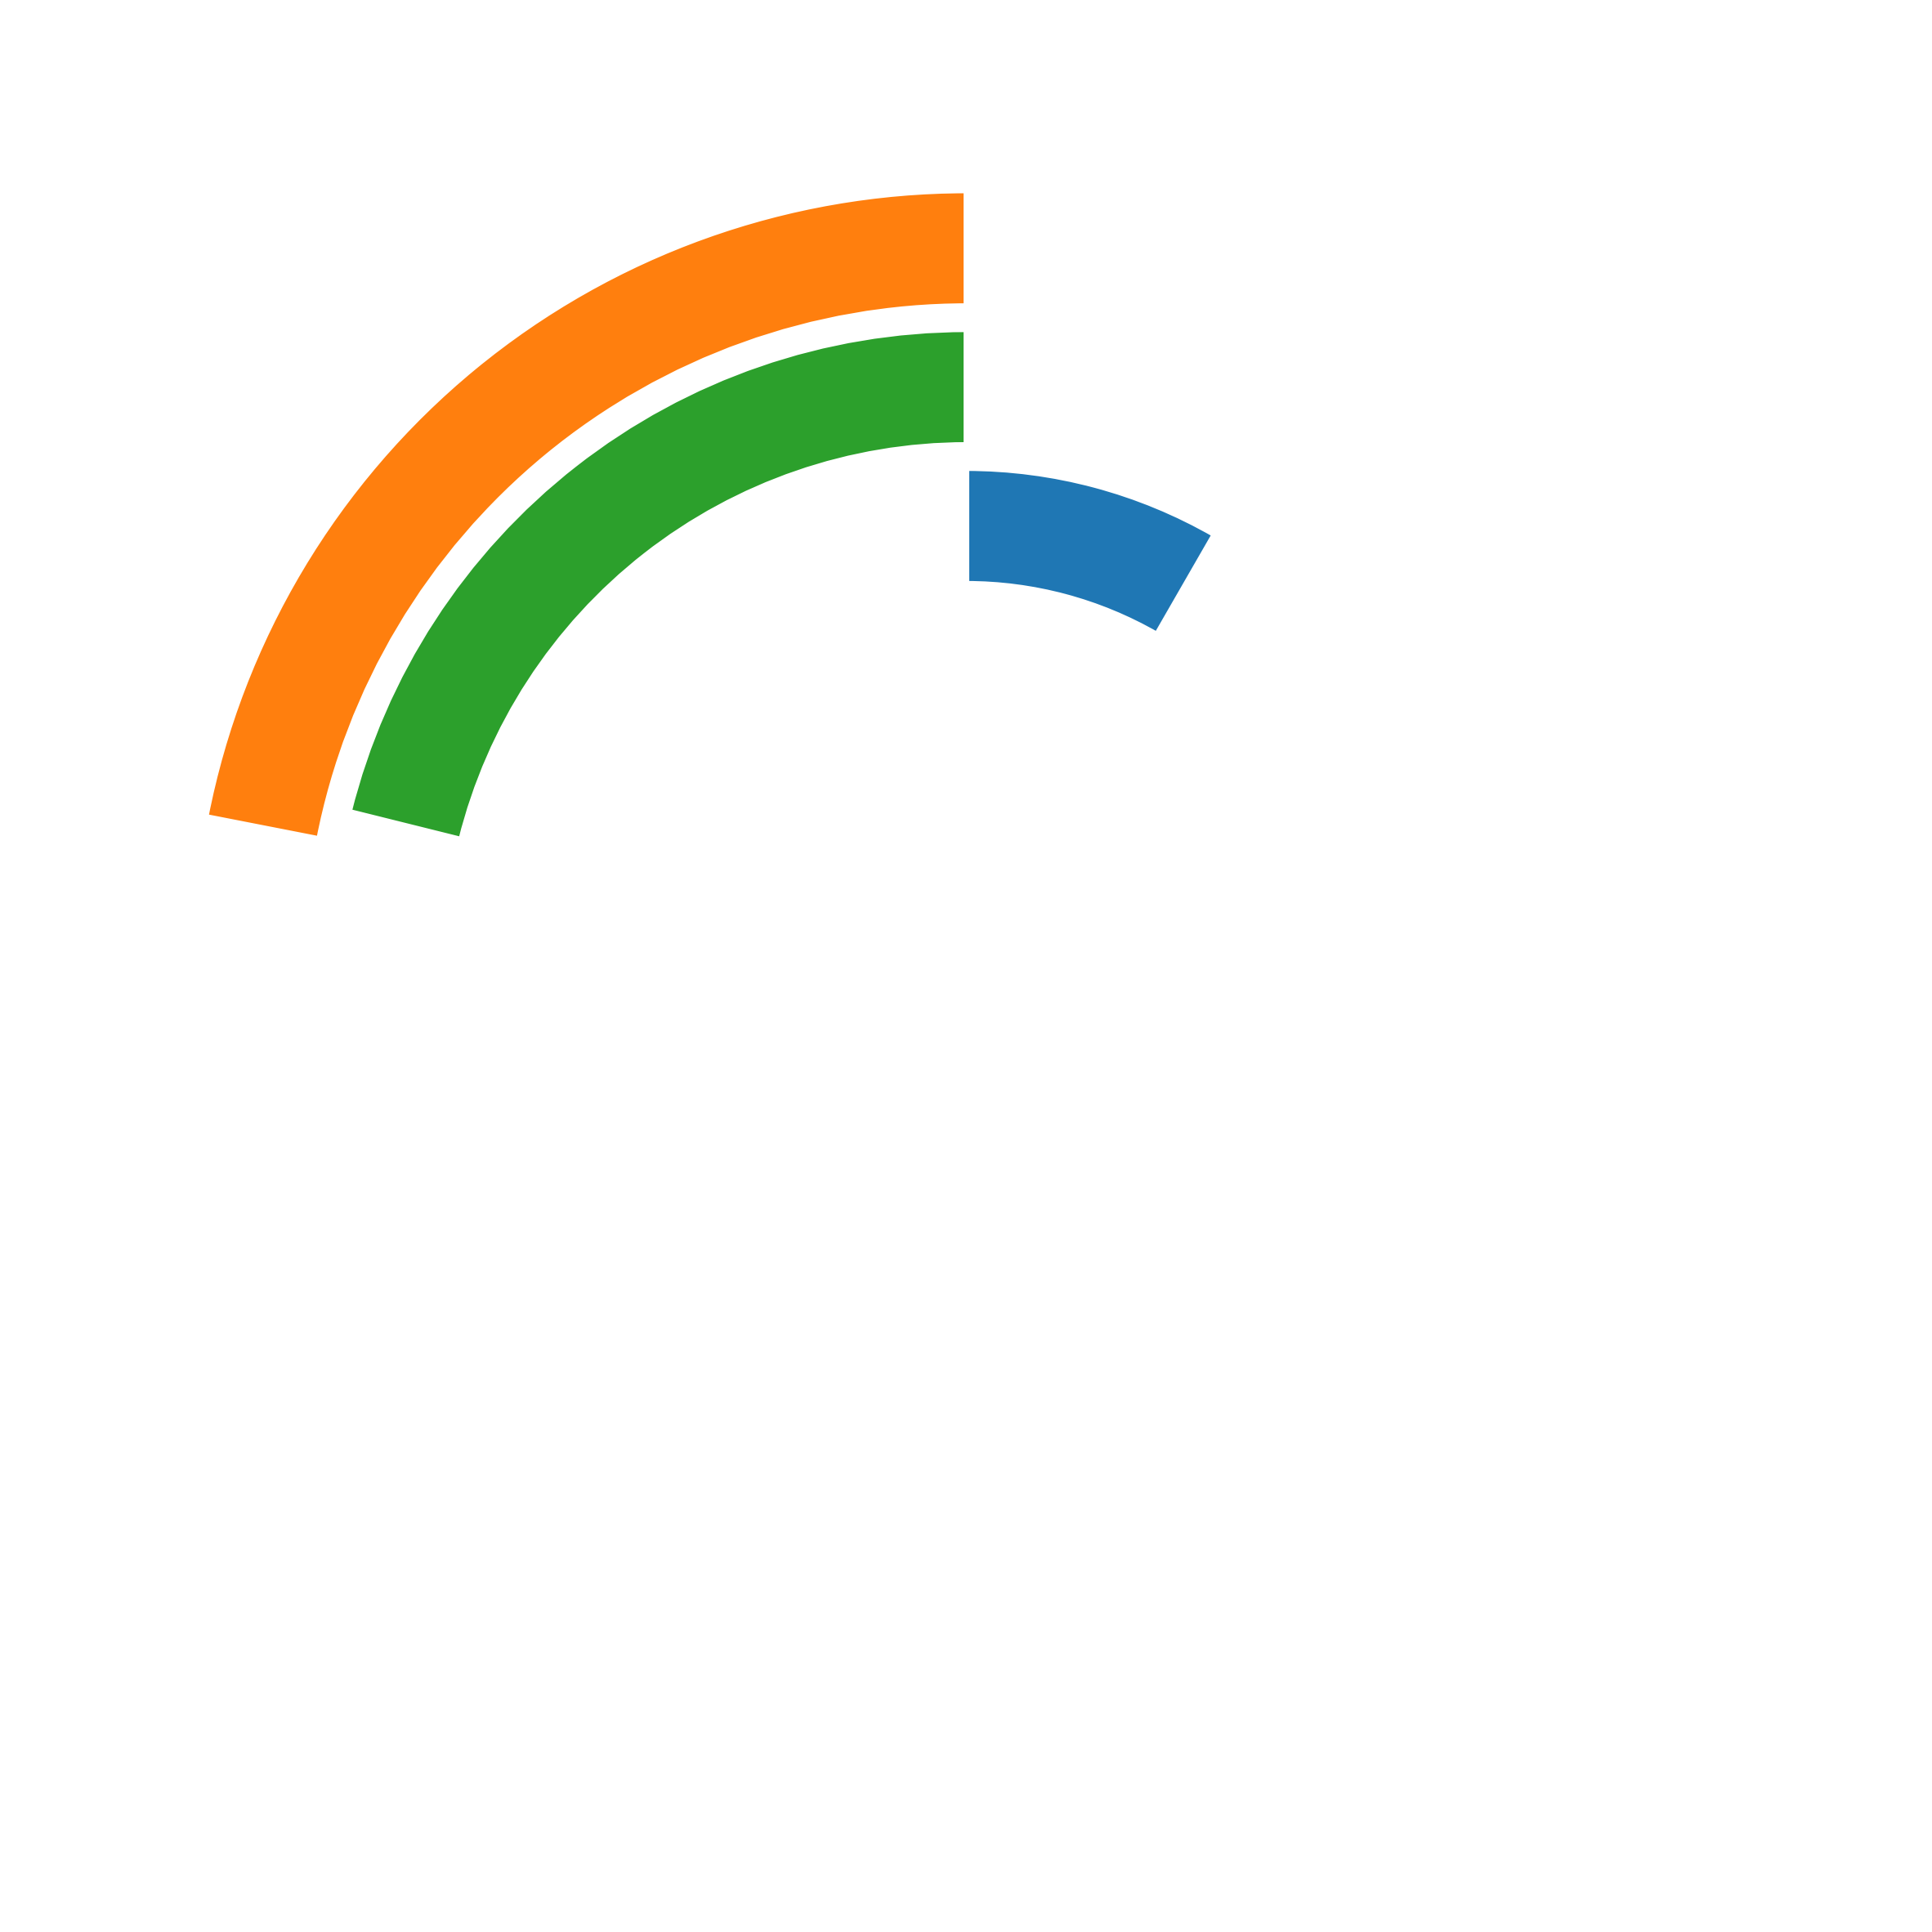

In [37]:
from math import pi
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 6))
ax = plt.subplot(projection='polar')
# data = driver
data = [-i for i in data]
# data = [i for i in data]
startangle = 90

colors = ['C0', 'C2', 'C1']
xs = [(i * pi *2)/ 100 for i in data]
ys = [-0.2, 1, 2.2]
left = (startangle * pi *2)/ 360 #this is to control where the bar starts

# plot bars and points at the end to make them round
for i, x in enumerate(xs):
    ax.barh(ys[i], x, left=left, height=1, color=colors[i])
    
plt.ylim(-4, 4)
# clear ticks, grids, spines
plt.xticks([])
plt.yticks([])
ax.spines.clear()
plt.savefig('Figs/1.3/P3_xx.png')